<h1 style="color:#D6336C;">Lung Segmentation on Chest X-Rays (DeepLabV3+)</h1>
<h3 style="color:#D6336C;">COVID-19 Radiography Database — CRISP-DM Pipeline</h3>

<h2 style="color:#D6336C;">1. Business Understanding</h2>

- **Business objective**: Provide a diagnostic-assistance tool that automatically locates the left and right lungs on a chest X-ray, as a preprocessing step for downstream pathology analysis (COVID-19, lung opacities, viral pneumonia).
- **Problem**: Manual segmentation is time-consuming and subject to inter-observer variability.
- **Success metric**: Dice coefficient / IoU per class (right lung, left lung) ≥ 0.90 on the test set.
- **Analytical approach**: Supervised multiclass semantic segmentation using **DeepLabV3+** (Chen et al., 2018) — an encoder/decoder that applies Atrous Spatial Pyramid Pooling (ASPP) to the encoder's deepest features to capture multi-scale context, then a lightweight decoder fuses this with a low-level encoder feature map to recover spatial detail. Two ImageNet-pretrained encoders are trained: **ResNet34** and **EfficientNet-B4**.
- **Expected output**: A 3-class mask (background, right lung, left lung)

Dataset

For our project, we are using the COVID-19 Radiography Database. This comprehensive database contains chest X-ray images for three distinct classes: COVID-19, normal, and viral pneumonia. Specifically, the dataset comprises 3616 images of COVID-19 positive cases, 10,192 images categorized as normal, and 1345 images identified as viral pneumonia. This extensive collection allows us to train our diagnostic models effectively, ensuring robust performance in identifying and classifying these conditions.

In [39]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Image processing
import cv2
from pathlib import Path
from scipy import ndimage

# Data handling
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from matplotlib.colors import ListedColormap

# Standard library
import os
import random
import pickle
import json
from collections import Counter

import warnings
warnings.filterwarnings('ignore')
import gc


<h2 style="color:#D6336C;">2. Data Understanding</h2>

<h3 style="color:#D6336C;">2.1 Raw Dataset Loading</h3>

In [40]:
class Config:
    # Data paths (confirmed structure: DATA_ROOT/<class>/images and /masks)
    DATA_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
    RESULTS_PATH = "/kaggle/working/results"

    SOURCES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]  

    # Hyperparameters
    IMG_SIZE = 256
    BATCH_SIZE = 4
    EPOCHS = 50
    LEARNING_RATE = 5.943707772991461e-05
    WEIGHT_DECAY = 1.0593208766487991e-07
    NUM_CLASSES = 3  # background, right lung, left lung

    # ReduceLROnPlateau scheduler -- a bit more "patient" for this larger LR
    LR_PATIENCE = 8
    LR_FACTOR = 0.5
    LR_THRESHOLD = 1e-5
    LR_MIN = 1e-6
    LR_COOLDOWN = 2

    # Train / val / test split
    TEST_SIZE = 0.15
    VAL_SIZE = 0.15

    # Reproducibility
    RANDOM_SEED = 42

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Per-class paths, built once
Config.IMG_PATHS = {src: os.path.join(Config.DATA_PATH, src, "images") for src in Config.SOURCES}
Config.MASK_PATHS = {src: os.path.join(Config.DATA_PATH, src, "masks") for src in Config.SOURCES}

os.makedirs(Config.RESULTS_PATH, exist_ok=True)

for src in Config.SOURCES:
    print(f"{src:20s} img: {os.path.exists(Config.IMG_PATHS[src])} | mask: {os.path.exists(Config.MASK_PATHS[src])}")


def set_seed(seed):
    """Fix every random seed for reproducibility (numpy, random, torch, cuDNN)."""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(Config.RANDOM_SEED)
print(f"Device in use: {Config.DEVICE}")

COVID                img: True | mask: True
Normal               img: True | mask: True
Lung_Opacity         img: True | mask: True
Viral Pneumonia      img: True | mask: True
Device in use: cuda


In [41]:
# ==== Copy checkpoint files from Kaggle input (nested anywhere) to the working results
#      folder, renaming them to match what run_experiment() expects to find. ====
import shutil
import glob

os.makedirs(Config.RESULTS_PATH, exist_ok=True)

VALID_TAGS = {
    "deeplab_resnet34": ["resnet34", "resnet_34", "deeplab_resnet"],
    "deeplab_effb4": ["effb4", "efficientnet", "efficientnet_b4", "eff_b4"],
}
VALID_KINDS = ["resume", "best", "final"]

def guess_tag(filename):
    name = filename.lower()
    for tag, keywords in VALID_TAGS.items():
        if any(kw in name for kw in keywords):
            return tag
    return None

def guess_kind(filename):
    name = filename.lower()
    for kind in VALID_KINDS:
        if kind in name:
            return kind
    return None

# Search everywhere under /kaggle/input for .pth files, however deeply nested
pth_files = glob.glob("/kaggle/input/**/*.pth", recursive=True)
print(f"Found {len(pth_files)} .pth file(s) under /kaggle/input:")
for f in pth_files:
    print(" -", f)

# Build the copy plan first and show it -- verify before actually copying
copy_plan = []
for src_path in pth_files:
    filename = os.path.basename(src_path)
    tag = guess_tag(filename)
    kind = guess_kind(filename)

    if tag is None or kind is None:
        print(f"\n[SKIPPED -- could not infer tag/kind] {src_path}")
        continue

    dst_filename = f"{tag}_{kind}.pth"
    dst_path = os.path.join(Config.RESULTS_PATH, dst_filename)
    copy_plan.append((src_path, dst_path))

print("\nPlanned copies:")
for src_path, dst_path in copy_plan:
    print(f"  {src_path}\n    -> {dst_path}")

# ---- Actually copy ----
for src_path, dst_path in copy_plan:
    shutil.copy2(src_path, dst_path)

print(f"\nDone. {len(copy_plan)} file(s) copied to {Config.RESULTS_PATH}.")

Found 0 .pth file(s) under /kaggle/input:

Planned copies:

Done. 0 file(s) copied to /kaggle/working/results.


<h3 style="color:#D6336C;">2.2 File Structure</h3>

In [42]:
# ==== Dataset structure ====
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
for src in Config.SOURCES:
    print(f"{src}/")
    print(f"  |-- images/ : {len(os.listdir(Config.IMG_PATHS[src]))} files")
    print(f"  `-- masks/  : {len(os.listdir(Config.MASK_PATHS[src]))} files")
print("=" * 60)

DATASET STRUCTURE
COVID/
  |-- images/ : 3616 files
  `-- masks/  : 3616 files
Normal/
  |-- images/ : 10192 files
  `-- masks/  : 10192 files
Lung_Opacity/
  |-- images/ : 6012 files
  `-- masks/  : 6012 files
Viral Pneumonia/
  |-- images/ : 1345 files
  `-- masks/  : 1345 files


In [43]:
# ==== Path pattern: one image, one mask, same filename under a different subfolder ====
sample_cls = "COVID"
sample_fname = sorted(os.listdir(Config.IMG_PATHS[sample_cls]))[0]

print("Image path  :", os.path.join(Config.IMG_PATHS[sample_cls], sample_fname))
print("Mask path :", os.path.join(Config.MASK_PATHS[sample_cls], sample_fname))


Image path  : /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images/COVID-1.png
Mask path : /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/masks/COVID-1.png


             Class  Image_count
0            COVID         3616
1           Normal        10192
2     Lung_Opacity         6012
3  Viral Pneumonia         1345

Total images: 21165


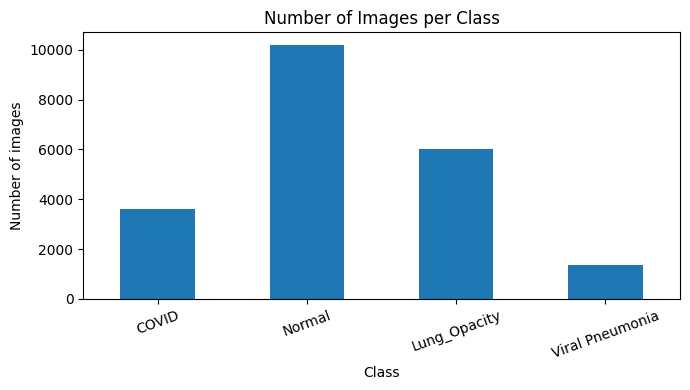

In [44]:
# ==== Image count per class ====

counts = {}

for cls in Config.SOURCES:
    img_dir = Config.IMG_PATHS[cls]
    counts[cls] = len([f for f in os.listdir(img_dir) if f.lower().endswith(".png")])

df_counts = pd.DataFrame(list(counts.items()),columns=["Class", "Image_count"])

print(df_counts)
print("\nTotal images:", df_counts["Image_count"].sum())
df_counts.plot( kind="bar", x="Class", y="Image_count", legend=False, figsize=(7, 4))
plt.title("Number of Images per Class")
plt.ylabel("Number of images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [45]:
# ==== File format check: extension, dimensions, channels ====
for src in Config.SOURCES:
    fname = sorted(os.listdir(Config.IMG_PATHS[src]))[0]
    ext = os.path.splitext(fname)[1]

    img_color = cv2.imread(os.path.join(Config.IMG_PATHS[src], fname), cv2.IMREAD_UNCHANGED)
    channels = 1 if img_color.ndim == 2 else img_color.shape[2]

    print(f"{src:<15} extension={ext}  shape={img_color.shape}  dtype={img_color.dtype}  channels={channels}")

COVID           extension=.png  shape=(299, 299)  dtype=uint8  channels=1
Normal          extension=.png  shape=(299, 299)  dtype=uint8  channels=1
Lung_Opacity    extension=.png  shape=(299, 299)  dtype=uint8  channels=1
Viral Pneumonia extension=.png  shape=(299, 299)  dtype=uint8  channels=1


In [46]:
# ==== Mask analysis ====

for src in Config.SOURCES:
    fname = sorted(os.listdir(Config.MASK_PATHS[src]))[0]
    path = os.path.join(Config.MASK_PATHS[src], fname)

    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    unique_values = np.unique(mask)

    is_binary = set(unique_values).issubset({0, 255})

    print(
        f"{src:<17} "
        f"shape={mask.shape}  "
        f"dtype={mask.dtype}  "
        f"min={mask.min()}  "
        f"max={mask.max()}  "
        f"unique={len(unique_values)}  "
        f"binary={is_binary}"
    )

COVID             shape=(256, 256)  dtype=uint8  min=0  max=255  unique=2  binary=True
Normal            shape=(256, 256)  dtype=uint8  min=0  max=255  unique=2  binary=True
Lung_Opacity      shape=(256, 256)  dtype=uint8  min=0  max=255  unique=2  binary=True
Viral Pneumonia   shape=(256, 256)  dtype=uint8  min=0  max=255  unique=2  binary=True


**Note**: at this stage, masks are still raw and **binary** (0 = background, 255 = lungs) — the right/left split into 3 classes (0/1/2) is a Data Preparation step (see Section 3.3), since it requires processing (erosion, connected components) rather than simple inspection. The histogram below reflects the binary distribution actually present in the raw files.

<h3 style="color:#D6336C;">2.3 Example Visualization</h3>

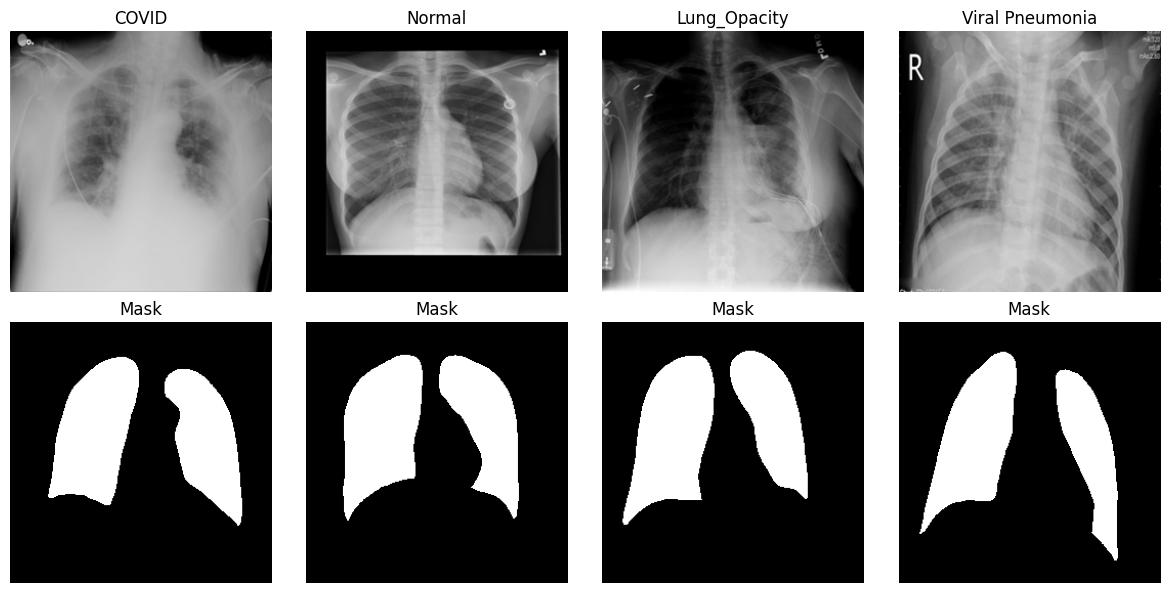

In [47]:
# ==== Visualize image and mask ====

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, src in enumerate(Config.SOURCES):
    fname = sorted(os.listdir(Config.IMG_PATHS[src]))[0]

    img = cv2.imread(
        os.path.join(Config.IMG_PATHS[src], fname),
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.imread(
        os.path.join(Config.MASK_PATHS[src], fname),
        cv2.IMREAD_GRAYSCALE
    )

    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(src)
    axes[0, i].axis("off")

    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title("Mask")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

The images have a mean intensity of 130.8 and a standard deviation of 63.5, indicating a moderate overall brightness with significant variation in pixel intensities

Background : 75.74%
Lung       : 24.26%


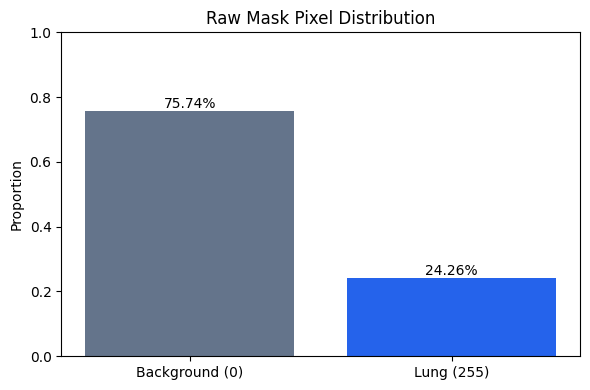

In [48]:
# ==== Raw mask pixel distribution ====

np.random.seed(Config.RANDOM_SEED)

bg, lung = 0, 0

for src in Config.SOURCES:
    files = sorted(os.listdir(Config.MASK_PATHS[src]))[:100]

    for f in files:
        mask = cv2.imread(
            os.path.join(Config.MASK_PATHS[src], f),
            cv2.IMREAD_GRAYSCALE
        )

        lung += np.sum(mask > 127)
        bg += np.sum(mask <= 127)

total = bg + lung

bg_pct = bg / total
lung_pct = lung / total

print(f"Background : {bg_pct:.2%}")
print(f"Lung       : {lung_pct:.2%}")

plt.figure(figsize=(6, 4))

bars = plt.bar(
    ["Background (0)", "Lung (255)"],
    [bg_pct, lung_pct],
    color=["#64748B", "#2563EB"]
)

for bar, pct in zip(bars, [bg_pct, lung_pct]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.2%}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Proportion")
plt.title("Raw Mask Pixel Distribution")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

This class imbalance indicates that the background represents a larger proportion of the pixels than the lung regions. Therefore, using a loss function such as Dice Loss combined with Cross-Entropy Loss is appropriate to prevent the model from being biased toward the background class.

<h2 style="color:#D6336C;">3. Data Preparation</h2>

In [49]:
# ==== Loading one category ====

def load_category(src):
    img_dir = Config.IMG_PATHS[src]
    mask_dir = Config.MASK_PATHS[src]

    images, masks = [], []

    filenames = sorted(os.listdir(img_dir))

    for fname in tqdm(filenames, desc=f"Loading {src}"):

        img = cv2.imread(
            os.path.join(img_dir, fname),
            cv2.IMREAD_GRAYSCALE
        )

        mask = cv2.imread(
            os.path.join(mask_dir, fname),
            cv2.IMREAD_GRAYSCALE
        )

        if img is not None and mask is not None:
            images.append(img)
            masks.append(mask)

    return np.array(images, dtype=np.uint8), np.array(masks, dtype=np.uint8)

In [50]:
# ==== Concatenate all categories ====

all_images = []
all_masks = []
all_labels_source = []

for src in Config.SOURCES:
    imgs, msks = load_category(src)

    all_images.append(imgs)
    all_masks.append(msks)
    all_labels_source.extend([src] * len(imgs))

X = np.concatenate(all_images, axis=0)
Y_binary = np.concatenate(all_masks, axis=0)

Loading Viral Pneumonia: 100%|██████████| 1345/1345 [00:05<00:00, 247.80it/s]


In [51]:
# ==== Sanity check ====
print("=" * 50)
print("RAW DATA SUMMARY")
print("=" * 50)
print(f"{'Images shape':<15}: {X.shape}")
print(f"{'Masks shape':<15}: {Y_binary.shape}")
print(f"{'Sources':<15}: {len(all_labels_source)}")
print(f"{'Image dtype':<15}: {X.dtype}")
print(f"{'Mask dtype':<15}: {Y_binary.dtype}")
print(f"{'Image range':<15}: {X.min()} - {X.max()}")
print(f"{'Mask values':<15}: {np.unique(Y_binary)}")
print("=" * 50)

assert len(X) == len(Y_binary) == len(all_labels_source)

RAW DATA SUMMARY
Images shape   : (21165, 299, 299)
Masks shape    : (21165, 256, 256)
Sources        : 21165
Image dtype    : uint8
Mask dtype     : uint8
Image range    : 0 - 255
Mask values    : [  0 255]


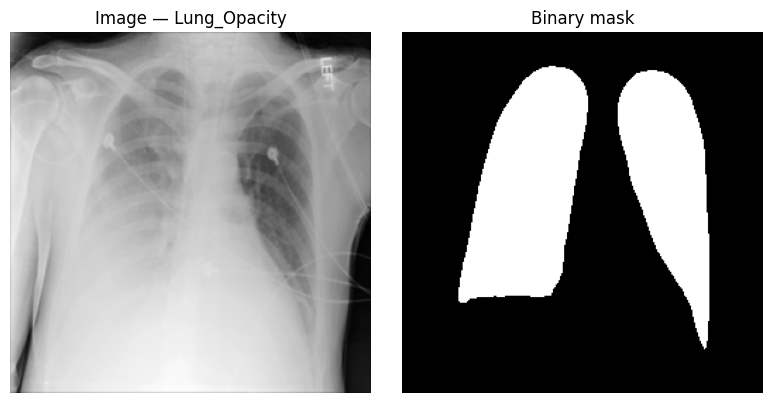

In [52]:
# ==== Visual sanity check ====

idx = np.random.randint(len(X))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(X[idx], cmap="gray")
plt.title(f"Image — {all_labels_source[idx]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Y_binary[idx], cmap="gray")
plt.title("Binary mask")
plt.axis("off")

plt.tight_layout()
plt.show()

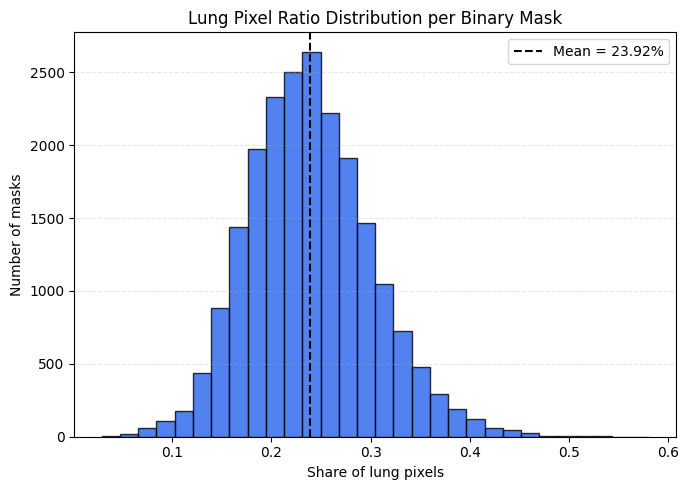

Mean ratio   : 23.92%
Median ratio : 23.54%
Min / Max    : 2.90% / 58.03%


In [53]:
# ==== Lung / background ratio distribution from binary masks ====

lung_pixels = np.sum(Y_binary > 127, axis=(1, 2))
total_pixels = Y_binary.shape[1] * Y_binary.shape[2]
ratios = lung_pixels / total_pixels

plt.figure(figsize=(7, 5))
plt.hist(ratios, bins=30, color="#2563EB", edgecolor="black", alpha=0.8)

plt.title("Lung Pixel Ratio Distribution per Binary Mask")
plt.xlabel("Share of lung pixels")
plt.ylabel("Number of masks")

mean_ratio = np.mean(ratios)

plt.axvline(
    mean_ratio,
    color="black",
    linestyle="--",
    label=f"Mean = {mean_ratio:.2%}"
)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean ratio   : {np.mean(ratios):.2%}")
print(f"Median ratio : {np.median(ratios):.2%}")
print(f"Min / Max    : {np.min(ratios):.2%} / {np.max(ratios):.2%}")

In [54]:
zero_ratio_idx = np.where(ratios == 0)[0]

print("Number of empty masks:", len(zero_ratio_idx))
print("Indices:", zero_ratio_idx[:20])

Number of empty masks: 0
Indices: []


<h3 style="color:#D6336C;">3.1 Binary Mask Filtering</h3>

In [55]:
# ==== Mask filtering ====

def filter_mask(mask):
    binary = (mask > 127).astype(np.uint8)
    # No foreground pixels -> return an all-zero mask
    if np.sum(binary) == 0:
        return binary

    # Composantes connexes
    n, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if n <= 2:
        return binary

    # Garder les deux plus grandes composantes
    largest = np.argsort(stats[1:, cv2.CC_STAT_AREA])[-2:] + 1
    return np.isin(labels, largest).astype(np.uint8)

Y_filtered = np.array([
    filter_mask(mask)
    for mask in tqdm(Y_binary, desc="Filtering masks")
], dtype=np.uint8)

print("Shape :", Y_filtered.shape)
print("Values:", np.unique(Y_filtered))

Filtering masks: 100%|██████████| 21165/21165 [00:18<00:00, 1160.99it/s]


Shape : (21165, 256, 256)
Values: [0 1]


Although the provided masks are theoretically binary (0 = background, 255 = lungs), a safety threshold at 127 is applied to remove intermediate values introduced by JPEG compression or resampling artifacts. This guarantees strictly binary masks before applying morphology and connected-component selection.

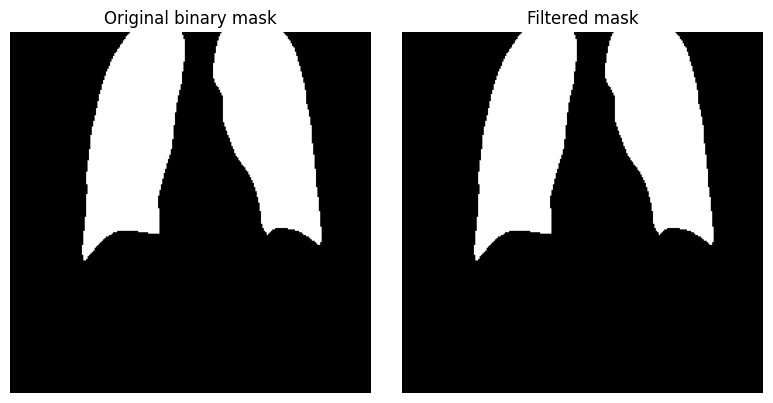

In [56]:
# ==== Filtering sanity check ====

idx = np.random.randint(len(Y_binary))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(Y_binary[idx], cmap="gray")
ax[0].set_title("Original binary mask")
ax[0].axis("off")

ax[1].imshow(Y_filtered[idx], cmap="gray")
ax[1].set_title("Filtered mask")
ax[1].axis("off")

plt.tight_layout()
plt.show()

<h3 style="color:#D6336C;">3.2 Patient / Data Leakage Verification</h3>

The COVID-19 Radiography Database aggregates images from several public sources without an explicit patient identifier. To guard against data leakage (the same image, or a near-duplicate, appearing in both train and test), a perceptual-hash duplicate check is performed on the full dataset **before** the train/val/test split (both exact-hash matches and near-duplicates caught via Hamming distance -- see the next cell), and duplicates are removed. A post-split verification (Section 3.4 bis, after the split cell) then confirms no residual exact-duplicate leakage remains.

**Limitation.** This process detects duplicate *images*, not duplicate *patients*. Because this dataset does not expose patient identifiers, two different images of the same patient (e.g. two exposures from the same visit, or follow-up scans) are not necessarily near-duplicates of each other and would not be caught by this check -- they could still end up split across train/val/test. The correct claim is therefore *"no exact or near-duplicate image leakage was detected, and the data were stratified by source class"*, **not** *"no patient leakage"*: patient-level leakage cannot be fully excluded with the metadata available. This is stated explicitly as a limitation in the report.

In [57]:
# ==== Global deduplication by perceptual hash (before multiclass mask generation) ====
import imagehash
from PIL import Image
from collections import defaultdict

def compute_phash(arr):
    return str(imagehash.phash(Image.fromarray(arr)))

hash_to_indices = defaultdict(list)
for i, img in enumerate(X):
    h = compute_phash(img)
    hash_to_indices[h].append(i)

duplicate_groups = {h: idxs for h, idxs in hash_to_indices.items() if len(idxs) > 1}
n_removed = sum(len(idxs) - 1 for idxs in duplicate_groups.values())

print(f"Duplicate groups found : {len(duplicate_groups)}")
print(f"Duplicate images to remove : {n_removed}")

Duplicate groups found : 178
Duplicate images to remove : 223


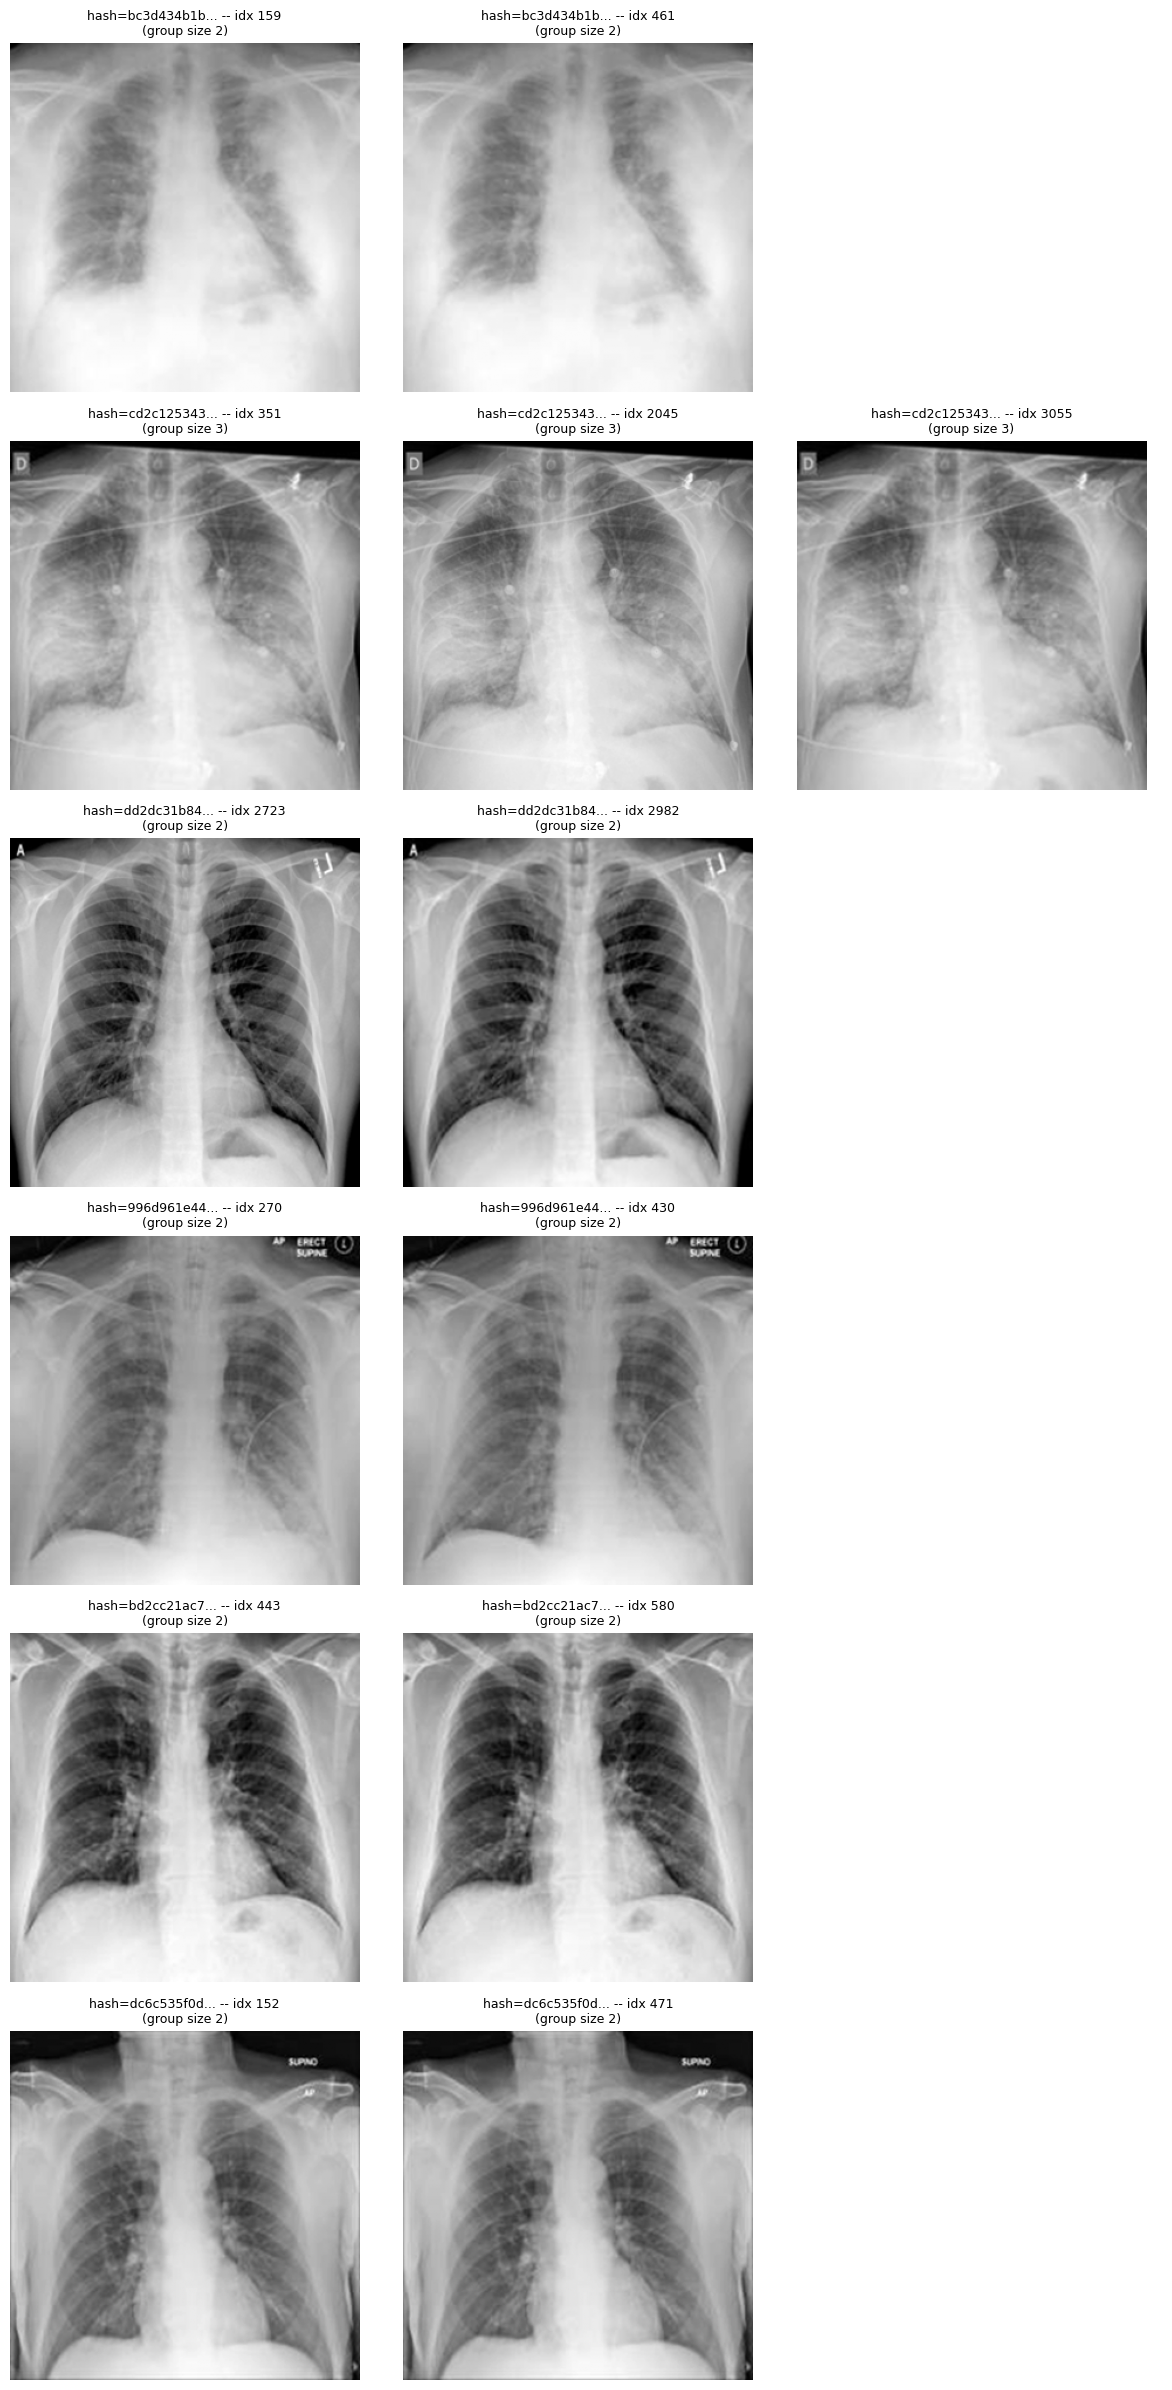

In [58]:
# ==== Visualize sample duplicate groups found by exact pHash match ====
N_GROUPS = 6         # number of groups to sample
N_PER_GROUP = 3       # max images shown per group

np.random.seed(Config.RANDOM_SEED)

group_items = list(duplicate_groups.items())
sample_groups = [group_items[k] for k in np.random.choice(
    len(group_items), min(N_GROUPS, len(group_items)), replace=False
)]

max_cols = max(min(len(idxs), N_PER_GROUP) for _, idxs in sample_groups)
fig, axes = plt.subplots(len(sample_groups), max_cols, figsize=(4 * max_cols, 4 * len(sample_groups)))
if len(sample_groups) == 1:
    axes = axes.reshape(1, -1)

for row, (h, idxs) in enumerate(sample_groups):
    shown = idxs[:N_PER_GROUP]
    for col in range(max_cols):
        ax = axes[row, col]
        if col < len(shown):
            idx = shown[col]
            ax.imshow(X[idx], cmap="gray")
            ax.set_title(f"hash={h[:10]}... -- idx {idx}\n(group size {len(idxs)})", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [59]:
# ==== Apply deduplication (Y multiclass masks not generated yet -- generated after this) ====
keep_mask = np.ones(len(X), dtype=bool)
for idxs in duplicate_groups.values():
    for dup_idx in idxs[1:]:
        keep_mask[dup_idx] = False

X = X[keep_mask]
Y_binary = Y_binary[keep_mask]
Y_filtered = Y_filtered[keep_mask]
all_labels_source = [s for i, s in enumerate(all_labels_source) if keep_mask[i]]

print(f"Dataset size after deduplication : {X.shape[0]} images")

Dataset size after deduplication : 20942 images


<h3 style="color:#D6336C;">3.3 Multiclass Mask Encoding</h3>

In [60]:
def split_left_right(mask_binary):
    """
    Transforme un masque pulmonaire binaire en masque multiclasses.

    0 : background
    1 : poumon droit du patient
    2 : poumon gauche du patient

    L'érosion est utilisée uniquement pour trouver deux graines.
    Le masque multiclasses final conserve tous les pixels
    du masque binaire original.
    """

    binary = (mask_binary > 0).astype(np.uint8)

    if binary.sum() == 0:
        return np.zeros_like(binary, dtype=np.uint8)

    kernel = np.ones((3, 3), dtype=np.uint8)

    # Tentative 1 : légère érosion.
    eroded = cv2.erode(binary, kernel, iterations=1)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        eroded,
        connectivity=8
    )

    foreground_ids = np.arange(1, num_labels)

    # Tentative 2 : si les poumons restent connectés.
    if len(foreground_ids) < 2:
        eroded = cv2.erode(binary, kernel, iterations=2)

        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            eroded,
            connectivity=8
        )

        foreground_ids = np.arange(1, num_labels)

    # Cas rare : fallback qui conserve obligatoirement tous les pixels.
    if len(foreground_ids) < 2:
        h, w = binary.shape
        x_mid = w // 2

        multiclass = np.zeros_like(binary, dtype=np.uint8)

        # À gauche dans l'image : classe 1.
        multiclass[:, :x_mid][binary[:, :x_mid] > 0] = 1

        # À droite dans l'image : classe 2.
        multiclass[:, x_mid:][binary[:, x_mid:] > 0] = 2

        return multiclass

    # Garder les deux plus grandes composantes.
    two_largest = foreground_ids[
        np.argsort(stats[foreground_ids, cv2.CC_STAT_AREA])[-2:]
    ]

    # Trier de gauche vers droite selon le centroïde horizontal.
    image_left_id, image_right_id = sorted(
        two_largest,
        key=lambda component_id: centroids[component_id][0]
    )

    # Création des graines dans les régions érodées.
    seeds = np.zeros_like(binary, dtype=np.uint8)

    # Convention retenue dans le notebook :
    # côté gauche de l'image -> classe 1
    # côté droit de l'image -> classe 2
    seeds[labels == image_left_id] = 1
    seeds[labels == image_right_id] = 2

    # Propagation : chaque pixel reçoit la classe de la graine la plus proche.
    _, nearest_indices = ndimage.distance_transform_edt(
        seeds == 0,
        return_indices=True
    )

    propagated = seeds[
        nearest_indices[0],
        nearest_indices[1]
    ]

    # Point essentiel : ne garder les labels que dans le masque ORIGINAL.
    multiclass = np.where(
        binary > 0,
        propagated,
        0
    ).astype(np.uint8)

    return multiclass

In [61]:
# ==== Generate multiclass masks 

Y = np.array(
    [
        split_left_right(mask)
        for mask in tqdm(Y_filtered, desc="Generating multiclass masks")
    ],
    dtype=np.uint8
)

print("Multiclass masks shape :", Y.shape)
print("Classes present        :", np.unique(Y))

Generating multiclass masks: 100%|██████████| 20942/20942 [01:43<00:00, 202.02it/s]


Multiclass masks shape : (20942, 256, 256)
Classes present        : [0 1 2]


<h3 style="color:#D6336C;">3.3 bis Label Sanity Check</h3>

In [62]:
# ==== Verify multiclass mask labels are exactly {0, 1, 2} ====
# CrossEntropyLoss (inside combined_loss) silently misbehaves if the masks contain values
# outside [0, num_classes), so this is checked explicitly rather than assumed.
unique_labels = np.unique(Y)
print(f"Unique values in Y (all masks, pre-split): {unique_labels}")
assert set(unique_labels.tolist()).issubset({0, 1, 2}), \
    f"Unexpected label values found: {unique_labels} -- expected a subset of {{0, 1, 2}}"
print("OK -- all mask labels are within {0, 1, 2} (background, right lung, left lung).")


Unique values in Y (all masks, pre-split): [0 1 2]
OK -- all mask labels are within {0, 1, 2} (background, right lung, left lung).


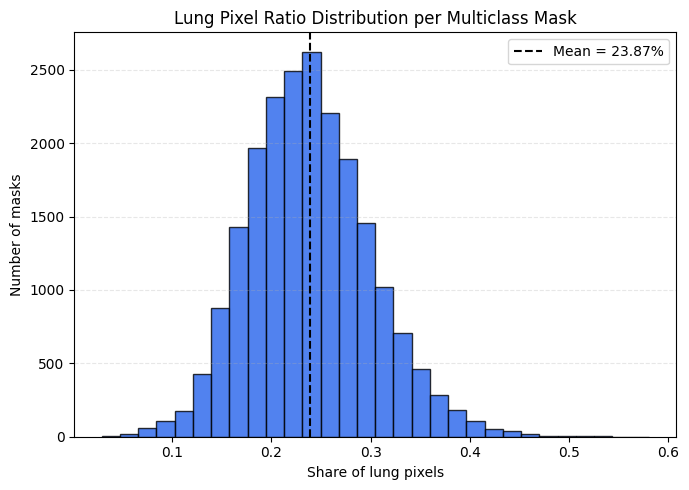

Mean ratio   : 23.87%
Median ratio : 23.51%
Min / Max    : 2.90% / 58.03%


In [63]:
# ==== 1. Lung / background ratio distribution, computed on the multiclass masks ====
CLASS_RIGHT, CLASS_LEFT = 1, 2
total_pixels = Y.shape[1] * Y.shape[2]

right_ratio = np.sum(Y == CLASS_RIGHT, axis=(1, 2)) / total_pixels
left_ratio  = np.sum(Y == CLASS_LEFT, axis=(1, 2)) / total_pixels
ratios = np.sum(Y > 0, axis=(1, 2)) / total_pixels  # ratio total (droit + gauche)

plt.figure(figsize=(7, 5))
plt.hist(ratios, bins=30, color="#2563EB", edgecolor="black", alpha=0.8)
plt.title("Lung Pixel Ratio Distribution per Multiclass Mask")
plt.xlabel("Share of lung pixels")
plt.ylabel("Number of masks")

mean_ratio = np.mean(ratios)
plt.axvline(mean_ratio, color="black", linestyle="--", label=f"Mean = {mean_ratio:.2%}")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean ratio   : {np.mean(ratios):.2%}")
print(f"Median ratio : {np.median(ratios):.2%}")
print(f"Min / Max    : {np.min(ratios):.2%} / {np.max(ratios):.2%}")

In [64]:
# ==== 2. Detecting problematic masks: empty lungs + extreme right/left area imbalance ====
CLASS_RIGHT, CLASS_LEFT = 1, 2
total_pixels = Y.shape[1] * Y.shape[2]
right_ratio = np.sum(Y == CLASS_RIGHT, axis=(1, 2)) / total_pixels
left_ratio  = np.sum(Y == CLASS_LEFT, axis=(1, 2)) / total_pixels

# --- Case 1: one lung completely missing ---
zero_right_idx = np.where(right_ratio == 0)[0]
zero_left_idx  = np.where(left_ratio == 0)[0]
zero_one_lung_idx = np.union1d(zero_right_idx, zero_left_idx)

print("Number of masks with at least one empty lung:", len(zero_one_lung_idx))
print("Indices:", zero_one_lung_idx[:20].tolist())

# --- Case 2: both lungs present but with an anatomically implausible area ratio ---

RATIO_THRESHOLD = 8.0  # one lung more than 8x the pixel area of the other -> suspicious

both_present_mask = (right_ratio > 0) & (left_ratio > 0)  # avoids divide-by-zero on the
                                                            # already-flagged empty-lung cases
area_ratio = np.full(len(Y), np.nan)
area_ratio[both_present_mask] = (
    np.maximum(right_ratio, left_ratio)[both_present_mask]
    / np.minimum(right_ratio, left_ratio)[both_present_mask]
)
extreme_imbalance_idx = np.where(area_ratio > RATIO_THRESHOLD)[0]

print(f"\nMasks with right/left area ratio > {RATIO_THRESHOLD}: {len(extreme_imbalance_idx)}")
print("Indices:", extreme_imbalance_idx[:20].tolist())

# --- Combined list of problematic masks (union of both cases, deduplicated) ---
problematic_idx = np.union1d(zero_one_lung_idx, extreme_imbalance_idx)
print(f"\nTotal problematic masks (union): {len(problematic_idx)}")
print("Indices:", problematic_idx.tolist())


Number of masks with at least one empty lung: 1
Indices: [17250]

Masks with right/left area ratio > 8.0: 3
Indices: [868, 11937, 17528]

Total problematic masks (union): 4
Indices: [868, 11937, 17250, 17528]


In [65]:
# ==== 4. Applying the combined filter ====
keep_mask = np.ones(len(X), dtype=bool)
keep_mask[problematic_idx] = False

X, Y_binary, Y_filtered, Y = X[keep_mask], Y_binary[keep_mask], Y_filtered[keep_mask], Y[keep_mask]
all_labels_source = [s for i, s in enumerate(all_labels_source) if keep_mask[i]]

print(f"Removed {len(problematic_idx)} problematic mask(s).")
print(f"X: {X.shape} | Y: {Y.shape} | sources: {len(all_labels_source)}")


Removed 4 problematic mask(s).
X: (20938, 299, 299) | Y: (20938, 256, 256) | sources: 20938


<h3 style="color:#D6336C;">3.4 Train / Validation / Test Split</h3>

In [66]:
# ==== Train / Val / Test split (stratified by source class) ====
X_train, X_temp, Y_train, Y_temp, src_train, src_temp = train_test_split(
    X, Y, all_labels_source,
    test_size=(Config.TEST_SIZE + Config.VAL_SIZE),
    stratify=all_labels_source,
    random_state=Config.RANDOM_SEED
)

relative_test_size = Config.TEST_SIZE / (Config.TEST_SIZE + Config.VAL_SIZE)

X_val, X_test, Y_val, Y_test, src_val, src_test = train_test_split(
    X_temp, Y_temp, src_temp,
    test_size=relative_test_size,
    stratify=src_temp,
    random_state=Config.RANDOM_SEED
)

print(f"Train : {X_train.shape[0]} images")
print(f"Val   : {X_val.shape[0]} images")
print(f"Test  : {X_test.shape[0]} images")

print("\nClass distribution in Train:")
print(Counter(src_train))
print("\nClass distribution in Val:")
print(Counter(src_val))
print("\nClass distribution in Test:")
print(Counter(src_test))

Train : 14656 images
Val   : 3141 images
Test  : 3141 images

Class distribution in Train:
Counter({'Normal': 7132, 'Lung_Opacity': 4207, 'COVID': 2381, 'Viral Pneumonia': 936})

Class distribution in Val:
Counter({'Normal': 1529, 'Lung_Opacity': 901, 'COVID': 510, 'Viral Pneumonia': 201})

Class distribution in Test:
Counter({'Normal': 1528, 'Lung_Opacity': 902, 'COVID': 510, 'Viral Pneumonia': 201})


<h3 style="color:#D6336C;">3.4 bis Post-Split Leakage Verification</h3>

In [67]:
# ==== Post-split verification: confirm no residual leakage ====
import hashlib

def hash_array(arr):
    return hashlib.md5(arr.tobytes()).hexdigest()

train_hashes = set(hash_array(img) for img in X_train)
val_hashes   = set(hash_array(img) for img in X_val)
test_hashes  = set(hash_array(img) for img in X_test)

n_train_val  = len(train_hashes & val_hashes)
n_train_test = len(train_hashes & test_hashes)
n_val_test   = len(val_hashes & test_hashes)

print(f"Exact duplicates train ∩ val  : {n_train_val}")
print(f"Exact duplicates train ∩ test : {n_train_test}")
print(f"Exact duplicates val ∩ test   : {n_val_test}")

assert n_train_val == 0 and n_train_test == 0 and n_val_test == 0, \
    "Residual leakage detected — check deduplication logic"

print("\n No leakage detected between splits.")


Exact duplicates train ∩ val  : 0
Exact duplicates train ∩ test : 0
Exact duplicates val ∩ test   : 0

 No leakage detected between splits.


In [68]:
# ==== Verify labels again, per split (after the stratified split) ====
# A bug in indexing/stratification could in principle scramble which mask goes with which
# split; re-checking here (rather than trusting the pre-split check alone) costs nothing.
for split_name, Y_split in [("train", Y_train), ("val", Y_val), ("test", Y_test)]:
    vals = np.unique(Y_split)
    print(f"{split_name:5s} unique labels: {vals}")
    assert set(vals.tolist()).issubset({0, 1, 2}), f"{split_name} split has unexpected labels: {vals}"
print("OK -- train/val/test masks all use only {0, 1, 2}.")


train unique labels: [0 1 2]
val   unique labels: [0 1 2]
test  unique labels: [0 1 2]
OK -- train/val/test masks all use only {0, 1, 2}.


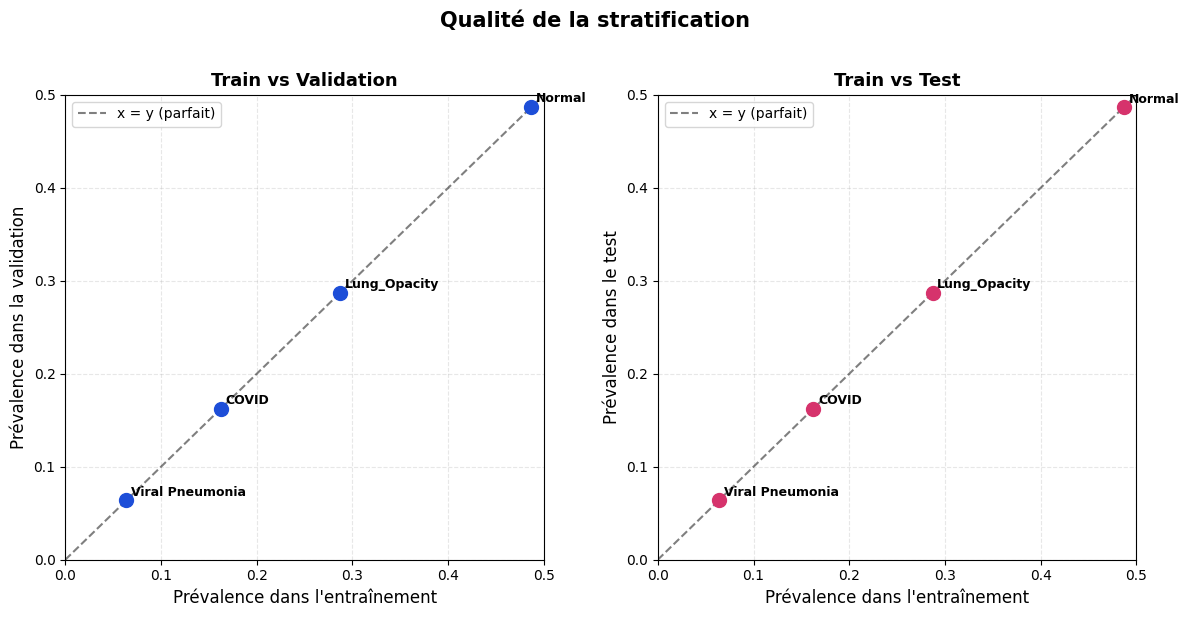

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import os

classes = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

train_dist = Counter(src_train)
val_dist   = Counter(src_val)
test_dist  = Counter(src_test)

n_train, n_val, n_test = len(src_train), len(src_val), len(src_test)

train_prevalence = [train_dist[c] / n_train for c in classes]
val_prevalence   = [val_dist[c] / n_val for c in classes]
test_prevalence  = [test_dist[c] / n_test for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

min_val, max_val = 0, 0.5

# ---- Panneau 1 : Train vs Val ----
ax = axes[0]
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='x = y (parfait)')
ax.scatter(train_prevalence, val_prevalence, color='#1D4ED8', s=100, zorder=5)
for i, cls in enumerate(classes):
    ax.annotate(cls, (train_prevalence[i] + 0.005, val_prevalence[i] + 0.005),
                fontsize=9, fontweight='bold')
ax.set_xlabel('Prévalence dans l\'entraînement', fontsize=12)
ax.set_ylabel('Prévalence dans la validation', fontsize=12)
ax.set_title('Train vs Validation', fontsize=13, fontweight='bold')
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend()

# ---- Panneau 2 : Train vs Test ----
ax = axes[1]
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='x = y (parfait)')
ax.scatter(train_prevalence, test_prevalence, color='#D6336C', s=100, zorder=5)
for i, cls in enumerate(classes):
    ax.annotate(cls, (train_prevalence[i] + 0.005, test_prevalence[i] + 0.005),
                fontsize=9, fontweight='bold')
ax.set_xlabel('Prévalence dans l\'entraînement', fontsize=12)
ax.set_ylabel('Prévalence dans le test', fontsize=12)
ax.set_title('Train vs Test', fontsize=13, fontweight='bold')
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend()

fig.suptitle('Qualité de la stratification', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/stratification_quality_combined.png', dpi=200, bbox_inches='tight')
plt.show()


<h3 style="color:#D6336C;">3.4 Image Preprocessing — Percentile + CLAHE + Resize</h3>

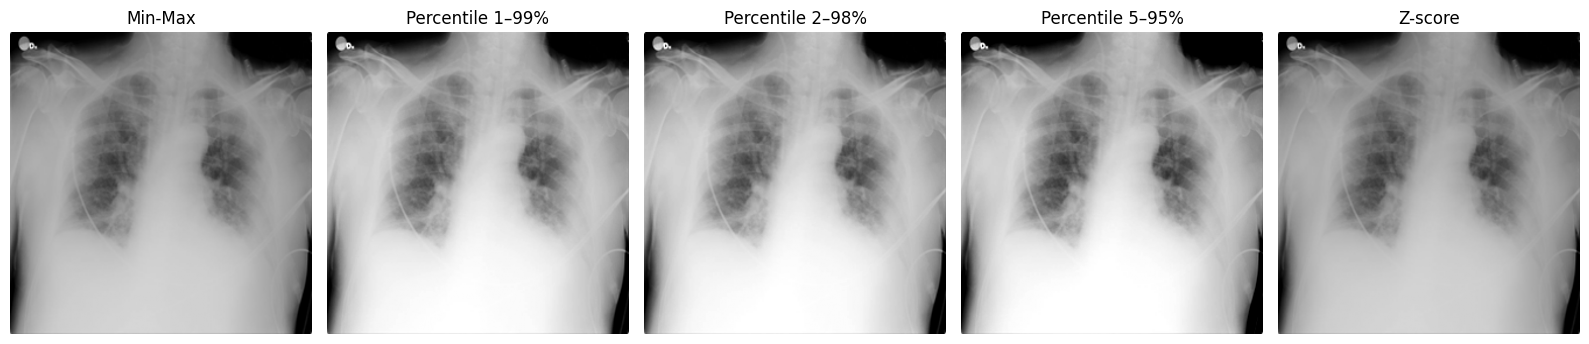

In [70]:
# ==== Normalization comparison ====

img = X[0].astype(np.float32)

# A — Min-Max
minmax = img / 255.0

# B — Percentiles
percentiles = []
for low, high in [(1, 99), (2, 98), (5, 95)]:
    p1, p99 = np.percentile(img, [low, high])
    norm = np.clip(img, p1, p99)
    norm = (norm - p1) / (p99 - p1)
    percentiles.append(norm)

# C — Z-score
zscore = (img - img.mean()) / (img.std() + 1e-8)

fig, ax = plt.subplots(1, 5, figsize=(16, 4))

images = [minmax, *percentiles, zscore]
titles = [
    "Min-Max",
    "Percentile 1–99%",
    "Percentile 2–98%",
    "Percentile 5–95%",
    "Z-score"
]

for a, im, title in zip(ax, images, titles):
    a.imshow(im, cmap="gray")
    a.set_title(title)
    a.axis("off")

plt.tight_layout()
plt.show()

Based on the visual comparison, percentile normalization with a 2–98% range provides a good balance between contrast enhancement and preservation of anatomical information. It was therefore selected as the primary normalization strategy, while the final choice will be validated experimentally using segmentation performance.

In [71]:
# ==== Step 1: Load image as grayscale ====
def load_gray(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(path)
    return img


# ==== Step 2: Percentile normalization (per image, rescales to 0-255) ====
def percentile_normalize(img, low=2, high=98):
    img = img.astype(np.float32)
    p_low, p_high = np.percentile(img, [low, high])
    img = np.clip(img, p_low, p_high)
    img = (img - p_low) / (p_high - p_low + 1e-8)
    return (img * 255).astype(np.uint8)


# ==== Step 3: CLAHE (local contrast enhancement) ====
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def apply_clahe(img):
    return _clahe.apply(img)


# ==== Step 4: Resize to fixed size ====
def resize_image(img, size=None, interpolation=cv2.INTER_LINEAR):
    size = size or Config.IMG_SIZE
    return cv2.resize(img, (size, size), interpolation=interpolation)


# ==== Step 5: Full pipeline, composed from the steps above ====
def prepare_image_array(img_gray):
    img = percentile_normalize(img_gray)
    img = apply_clahe(img)
    img = resize_image(img)
    return img


def preprocess_image(path):
    img = load_gray(path)
    return prepare_image_array(img)


# ==== Step 6: Z-score normalization (train stats, applied later in the Dataset) ====
def make_zscore_preprocessing(mean, std):
    def _preprocess(img_gray):
        img_norm = img_gray.astype(np.float32) / 255.0
        img_norm = (img_norm - mean) / std
        return img_norm[..., np.newaxis]
    return _preprocess

Percentile 2–98% stabilizes and enhances the useful global intensity range, while CLAHE improves local contrast. Combining both steps provides better visibility of pulmonary structures before feeding the images to the segmentation model.

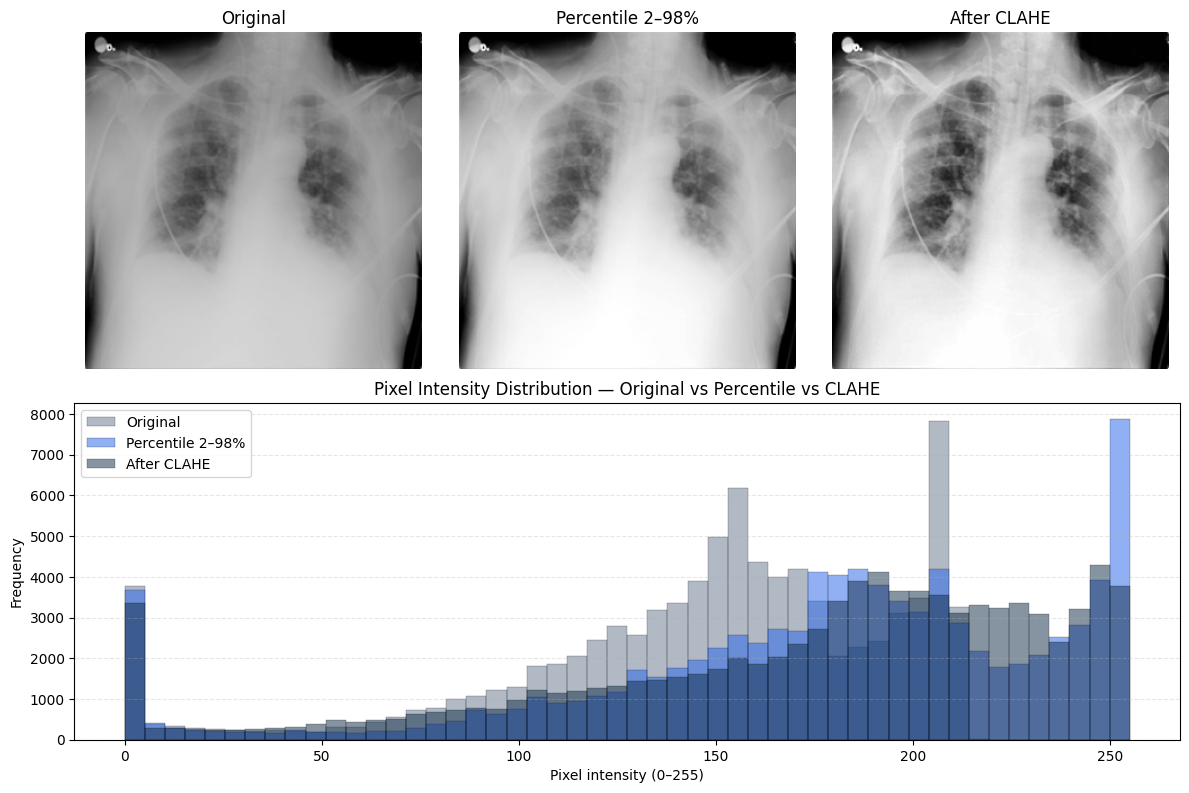

In [72]:
# ==== Example: Percentile normalization + CLAHE ====

path = os.path.join(
    Config.IMG_PATHS["COVID"],
    sorted(os.listdir(Config.IMG_PATHS["COVID"]))[0]
)

img = load_gray(path).astype(np.float32)

# Percentile 2–98%
p2, p98 = np.percentile(img, [2, 98])
img_percentile = np.clip(img, p2, p98)
img_percentile = ((img_percentile - p2) / (p98 - p2 + 1e-8) * 255).astype(np.uint8)

# CLAHE
img_clahe = apply_clahe(img_percentile)

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

ax_img0 = fig.add_subplot(gs[0, 0])
ax_img1 = fig.add_subplot(gs[0, 1])
ax_img2 = fig.add_subplot(gs[0, 2])
ax_hist = fig.add_subplot(gs[1, :])

ax_img0.imshow(img.astype(np.uint8), cmap="gray")
ax_img0.set_title("Original")
ax_img0.axis("off")

ax_img1.imshow(img_percentile, cmap="gray")
ax_img1.set_title("Percentile 2–98%")
ax_img1.axis("off")

ax_img2.imshow(img_clahe, cmap="gray")
ax_img2.set_title("After CLAHE")
ax_img2.axis("off")

# ==== Single combined histogram: intensity distribution at each preprocessing step ====
bins = np.linspace(0, 255, 51)

ax_hist.hist(img.ravel(), bins=bins, alpha=0.5, label="Original",
             color="#64748B", edgecolor="black", linewidth=0.3)
ax_hist.hist(img_percentile.ravel(), bins=bins, alpha=0.5, label="Percentile 2–98%",
             color="#2563EB", edgecolor="black", linewidth=0.3)
ax_hist.hist(img_clahe.ravel(), bins=bins, alpha=0.5, label="After CLAHE",
             color="#0F2A47", edgecolor="black", linewidth=0.3)

ax_hist.set_title("Pixel Intensity Distribution — Original vs Percentile vs CLAHE")
ax_hist.set_xlabel("Pixel intensity (0–255)")
ax_hist.set_ylabel("Frequency")
ax_hist.legend()
ax_hist.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


<h3 style="color:#D6336C;">3.5 Dataset, Augmentation &amp; Z-score Normalization</h3>

In [73]:
# ==== Z-score statistics — train set only ====
# Computed on the SAME prepared images (percentile -> CLAHE -> resize) the model actually
# trains on, not on the raw arrays -- otherwise the stats wouldn't match the real input
# distribution once percentile/CLAHE are applied.

X_train_prepared = np.stack([
    prepare_image_array(img)
    for img in tqdm(X_train, desc="Preparing train images for normalization stats")
])

Config.NORM_MEAN = float(X_train_prepared.mean() / 255.0)
Config.NORM_STD = float(X_train_prepared.std() / 255.0)

del X_train_prepared
gc.collect()

preprocess_fn = make_zscore_preprocessing(
    Config.NORM_MEAN,
    Config.NORM_STD
)

print(f"Mean (train): {Config.NORM_MEAN:.4f}")
print(f"Std  (train): {Config.NORM_STD:.4f}")

Preparing train images for normalization stats: 100%|██████████| 14656/14656 [00:34<00:00, 418.77it/s]


Mean (train): 0.5702
Std  (train): 0.2805


The models use pretrained ImageNet encoders but still take single-channel grayscale input (the first conv layer is adapted to 1 channel), so the `Dataset` below uses a single preprocessing function (z-score normalization using the train-set mean/std computed earlier in this section).

In [74]:
# ==== Data Augmentation — train set only ====

# ---- Geometric (affect image + mask) ----


def rotate(img, mask, angle_range=(-8, 8)):
    angle = np.random.uniform(*angle_range)
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)

    img = cv2.warpAffine(img, M, (w, h),flags=cv2.INTER_LINEAR,borderMode=cv2.BORDER_REFLECT)

    mask = cv2.warpAffine(mask, M, (w, h),flags=cv2.INTER_NEAREST,borderMode=cv2.BORDER_CONSTANT,borderValue=0)

    return img, mask


def random_scale(img, mask, scale_range=(0.9, 1.1)):
    factor = np.random.uniform(*scale_range)
    h, w = img.shape

    M = cv2.getRotationMatrix2D(
        (w // 2, h // 2), 0, factor
    )

    img = cv2.warpAffine(
        img, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    mask = cv2.warpAffine(
        mask, M, (w, h),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return img, mask


# ---- Photometric (image only) ----

def brightness_contrast(img, alpha_range=(0.9, 1.1), beta_range=(-15, 15)):
    alpha = np.random.uniform(*alpha_range)
    beta = np.random.uniform(*beta_range)
    img = alpha * img.astype(np.float32) + beta
    return np.clip(img, 0, 255).astype(np.uint8)


def gamma_correction(img, gamma_range=(0.7, 1.4)):
    gamma = np.random.uniform(*gamma_range)
    inv_gamma = 1.0 / gamma
    table = ((np.arange(256) / 255.0) ** inv_gamma * 255).astype(np.uint8)
    return cv2.LUT(img, table)


def gaussian_noise(img, std_range=(2, 6)):
    std = np.random.uniform(*std_range)
    noise = np.random.normal(0, std, img.shape)
    img = img.astype(np.float32) + noise
    return np.clip(img, 0, 255).astype(np.uint8)


def gaussian_blur(img, ksize_options=(3, 5)):
    ksize = int(np.random.choice(ksize_options))
    return cv2.GaussianBlur(img, (ksize, ksize), 0)


def motion_blur(img, ksize_range=(5, 12)):
    """Simulates patient/camera movement during acquisition."""
    ksize = int(np.random.uniform(*ksize_range))
    angle = np.random.uniform(0, 360)

    kernel = np.zeros((ksize, ksize), dtype=np.float32)
    kernel[ksize // 2, :] = 1.0
    M = cv2.getRotationMatrix2D((ksize // 2, ksize // 2), angle, 1.0)
    kernel = cv2.warpAffine(kernel, M, (ksize, ksize))
    kernel /= kernel.sum() + 1e-8

    return cv2.filter2D(img, -1, kernel)


def low_resolution(img, scale_range=(0.3, 0.6)):
    """Downscales then upscales back to simulate a lower-quality acquisition."""
    factor = np.random.uniform(*scale_range)
    h, w = img.shape
    small = cv2.resize(img, (max(1, int(w * factor)), max(1, int(h * factor))), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)


# ---- Combined pipeline ----

def augment_sample(img, mask):
   
    if np.random.rand() < 0.5:
        img, mask = rotate(img, mask)
    if np.random.rand() < 0.5:
        img, mask = random_scale(img, mask)

    # Photometric — image only, mutually exclusive blur choice (avoid over-blurring)
    if np.random.rand() < 0.5:
        img = brightness_contrast(img)
    if np.random.rand() < 0.3:
        img = gamma_correction(img)
    if np.random.rand() < 0.2:
        img = gaussian_noise(img)

    blur_roll = np.random.rand()
    if blur_roll < 0.15:
        img = gaussian_blur(img)
    elif blur_roll < 0.25:
        img = motion_blur(img)

    if np.random.rand() < 0.1:
        img = low_resolution(img)

    return img, mask

In [75]:
# ==== Verify augmentation preserves the label set {0, 1, 2} ====
# Geometric transforms use INTER_NEAREST + borderValue=0 for masks, so they should never
# introduce a value outside {0, 1, 2} -- confirmed empirically here over repeated random draws.
_sample_img, _sample_mask = X_train[0], Y_train[0]
for _ in range(20):
    _aug_img, _aug_mask = augment_sample(_sample_img.copy(), _sample_mask.copy())
    _vals = np.unique(_aug_mask)
    assert set(_vals.tolist()).issubset({0, 1, 2}), f"Augmentation introduced unexpected labels: {_vals}"
print("OK -- augmented masks stay within {0, 1, 2} across 20 repeated random augmentations.")


OK -- augmented masks stay within {0, 1, 2} across 20 repeated random augmentations.


In [76]:
class LungSegmentationDataset(Dataset):
    def __init__(self, X, Y, preprocessing_fn, augment=False, target_size=256):
        self.X = X
        self.Y = Y
        self.preprocessing_fn = preprocessing_fn
        self.augment = augment
        self.target_size = target_size

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        mask = self.Y[idx]

        # Same deterministic pipeline used everywhere: percentile normalize -> CLAHE -> resize.
        # (Previously this only resized and skipped percentile/CLAHE, while inference applied
        # CLAHE without percentile -- three different preprocessing paths. Now there is one.)
        img = prepare_image_array(img)

        if mask.shape[0] != self.target_size or mask.shape[1] != self.target_size:
            mask = cv2.resize(mask, (self.target_size, self.target_size), interpolation=cv2.INTER_NEAREST)

        mask = mask.copy()

        if self.augment:
            img, mask = augment_sample(img, mask)

        img = self.preprocessing_fn(img)
        img = img.transpose(2, 0, 1).astype(np.float32)

        mask = mask.astype(np.int64)

        return torch.from_numpy(img), torch.from_numpy(mask)

<h2 style="color:#D6336C;">4. Modeling</h2>

**DeepLabV3+** (Chen et al., 2018) applies Atrous (dilated) Spatial Pyramid Pooling to the encoder's deepest feature map, using several parallel dilated convolutions to capture context at multiple receptive-field scales without losing resolution. A lightweight decoder then upsamples this and fuses it with one low-level, high-resolution encoder feature map to sharpen object boundaries. It's implemented here with `segmentation_models_pytorch` (`smp.DeepLabV3Plus`), plugging in a pretrained encoder instead of training one from scratch. Two backbones are compared, **ResNet34** and **EfficientNet-B4**, each pretrained on ImageNet and adapted to single-channel grayscale input, each built and trained in its own cell below.

<h3 style="color:#D6336C;">4.1 Loss and Metrics (Dice, IoU, Pixel Accuracy — multiclass)</h3>

In [77]:
# ==== Dice & IoU — multiclass ====

def _softmax_and_onehot(y_pred, y_true, num_classes):
    pred = F.softmax(y_pred, dim=1)
    true = F.one_hot(
        y_true, num_classes=num_classes
    ).permute(0, 3, 1, 2).float()
    return pred, true


def dice_coef_multiclass(y_pred, y_true, num_classes=3, smooth=1.0):
    pred, true = _softmax_and_onehot(y_pred, y_true, num_classes)

    dims = (0, 2, 3)
    intersection = torch.sum(pred * true, dims)
    denom = torch.sum(pred, dims) + torch.sum(true, dims)

    dice = (2 * intersection + smooth) / (denom + smooth)

    return dice.mean(), dice


def iou_score_multiclass(y_pred, y_true, num_classes=3, smooth=1.0):
    pred, true = _softmax_and_onehot(y_pred, y_true, num_classes)

    dims = (0, 2, 3)
    intersection = torch.sum(pred * true, dims)
    union = torch.sum(pred, dims) + torch.sum(true, dims) - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.mean(), iou


def lung_dice_score(y_pred, y_true, num_classes=3):
    """
    Dice averaged over the lung classes only (right + left), excluding
    background. This is the metric that actually reflects the project's
    real objective -- background Dice is trivially high and would dilute it.
    """
    _, dice_per_class = dice_coef_multiclass(y_pred, y_true, num_classes)
    lung_dice = dice_per_class[1:].mean()
    return lung_dice, dice_per_class[1], dice_per_class[2]


def hard_dice_iou_per_class(y_pred, y_true, num_classes=3, eps=1e-7):
    """
    'Hard' Dice/IoU computed on the final discrete prediction (argmax), not on the
    softmax probabilities used by dice_coef_multiclass/iou_score_multiclass above.
    The soft version is a smooth, differentiable surrogate that is fine for the loss
    and for per-epoch monitoring, but it is NOT the number that should be reported as
    the model's segmentation quality -- that must come from the discrete prediction the
    model would actually output at inference time.

    Returns per-IMAGE tensors of shape (batch, num_classes), so that in addition to a
    per-class mean, per-image mean/median/std and worst-case images can be inspected.
    """
    pred = torch.argmax(y_pred, dim=1)  # (B, H, W)

    dice_per_image = torch.zeros(pred.size(0), num_classes)
    iou_per_image = torch.zeros(pred.size(0), num_classes)

    for c in range(num_classes):
        pred_c = (pred == c)
        true_c = (y_true == c)

        intersection = (pred_c & true_c).sum(dim=(1, 2)).float()
        pred_area = pred_c.sum(dim=(1, 2)).float()
        true_area = true_c.sum(dim=(1, 2)).float()
        union = pred_area + true_area - intersection

        dice_per_image[:, c] = (2 * intersection + eps) / (pred_area + true_area + eps)
        iou_per_image[:, c] = (intersection + eps) / (union + eps)

    return dice_per_image, iou_per_image


def pixel_accuracy(y_pred, y_true):
    pred = torch.argmax(y_pred, dim=1)
    return (pred == y_true).float().mean()


def combined_loss(y_pred, y_true, num_classes=3, dice_weight=0.5):
    ce = F.cross_entropy(y_pred, y_true)
    dice_loss = 1 - dice_coef_multiclass(
        y_pred, y_true, num_classes
    )[0]

    return dice_weight * dice_loss + (1 - dice_weight) * ce


criterion = lambda pred, true: combined_loss(
    pred,
    true,
    num_classes=Config.NUM_CLASSES,
    dice_weight=0.7
)

class_names = ["Background", "Right lung", "Left lung"]

<h3 style="color:#D6336C;">4.2 Training Utilities (AMP-enabled)</h3>

In [78]:
# ==== Single generic epoch loop, shared by training and validation ====
# Uses mixed precision (AMP) when running on GPU: forward pass + loss computed in float16,
# gradients scaled to avoid underflow. This roughly halves activation memory, giving
# headroom for the larger EfficientNet-B4 encoder without risking an OOM.

# ==== Generic training / validation epoch ====

USE_AMP = Config.DEVICE.type == "cuda"


def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    totals = {"loss": 0.0, "dice": 0.0, "iou": 0.0, "acc": 0.0, "lung_dice": 0.0}

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for imgs, masks in tqdm(
            loader,
            desc="Train" if is_train else "Val",
            leave=False
        ):
            imgs = imgs.to(Config.DEVICE)
            masks = masks.to(Config.DEVICE)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=Config.DEVICE.type,
                enabled=USE_AMP
            ):
                outputs = model(imgs)
                loss = criterion(outputs, masks)

            if is_train:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            # Metrics never participate in backprop -- compute them detached,
            # in float32, and under no_grad regardless of train/val to save
            # GPU memory and avoid any unnecessary graph tracking.
            with torch.no_grad():
                outputs_f32 = outputs.detach().float()

                dice_mean, _ = dice_coef_multiclass(
                    outputs_f32, masks, Config.NUM_CLASSES
                )

                iou_mean, _ = iou_score_multiclass(
                    outputs_f32, masks, Config.NUM_CLASSES
                )

                lung_dice, _, _ = lung_dice_score(
                    outputs_f32, masks, Config.NUM_CLASSES
                )

                acc = pixel_accuracy(outputs_f32, masks)

            bs = imgs.size(0)

            totals["loss"] += loss.item() * bs
            totals["dice"] += dice_mean.item() * bs
            totals["iou"] += iou_mean.item() * bs
            totals["acc"] += acc.item() * bs
            totals["lung_dice"] += lung_dice.item() * bs

    n = len(loader.dataset)

    return (
        totals["loss"] / n,
        totals["dice"] / n,
        totals["iou"] / n,
        totals["acc"] / n,
        totals["lung_dice"] / n
    )


def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    return run_epoch(model, loader, criterion, optimizer, scaler)


def validate_one_epoch(model, loader, criterion):
    return run_epoch(model, loader, criterion)


class EarlyStoppingCheckpoint:
    """
    Saves the best weights according to a monitored metric.

    monitor_mode = "min": lower is better, e.g. a loss.
    monitor_mode = "max": higher is better, e.g. Dice, IoU, or accuracy.
    min_delta: minimum improvement required to count as "improved",
    so the checkpoint isn't re-saved for negligible fluctuations.
    """

    def __init__(self, weight_path, monitor_mode='max', patience=15, min_delta=1e-4):
        self.weight_path = weight_path
        self.monitor_mode = monitor_mode
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, current_score, model):
        if self.best_score is None:
            improved = True
        elif self.monitor_mode == 'min':
            improved = current_score < (self.best_score - self.min_delta)
        elif self.monitor_mode == 'max':
            improved = current_score > (self.best_score + self.min_delta)
        else:
            raise ValueError("monitor_mode must be 'min' or 'max'")

        if improved:
            self.best_score = current_score
            self.counter = 0
            torch.save(model.state_dict(), self.weight_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def state_dict(self):
        return {"best_score": self.best_score, "counter": self.counter, "early_stop": self.early_stop}

    def load_state_dict(self, state):
        self.best_score = state["best_score"]
        self.counter = state["counter"]
        self.early_stop = state["early_stop"]


<h3 style="color:#D6336C;">4.3 DeepLabV3+ Architecture — dual backbones (ResNet34 / EfficientNet-B4)</h3>

In [79]:
# ==== DeepLabV3+ (Chen et al., 2018) via segmentation_models_pytorch ====
# ASPP module captures multi-scale context from the deepest encoder features; a
# lightweight decoder fuses it with one low-level feature map to sharpen boundaries.
# Two pretrained encoders are defined below, each in its own cell, and compared head-to-head.

!pip install segmentation-models-pytorch --quiet

import segmentation_models_pytorch as smp

# Decoder output width (DeepLabV3+ decoder is a single conv block, not a 5-stage stack)
DEEPLAB_DECODER_CHANNELS = 256


In [80]:
# ==== Backbone 1/2: DeepLabV3+ with a ResNet34 encoder ====

def build_model_resnet34():
    """DeepLabV3+ with a ResNet34 encoder pretrained on ImageNet."""
    return smp.DeepLabV3Plus(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        decoder_channels=DEEPLAB_DECODER_CHANNELS,
        in_channels=1,  # grayscale; smp averages the pretrained RGB filters into 1 channel
        classes=Config.NUM_CLASSES,
    ).to(Config.DEVICE)


_tmp_model = build_model_resnet34()
n_params = sum(p.numel() for p in _tmp_model.parameters())
print(f"DeepLabV3+ (ResNet34) -> {n_params / 1e6:.2f}M parameters")
del _tmp_model
gc.collect()
torch.cuda.empty_cache()


DeepLabV3+ (ResNet34) -> 22.43M parameters


In [81]:
# ==== Backbone 2/2: DeepLabV3+ with an EfficientNet-B4 encoder ====

def build_model_efficientnet_b4():
    """DeepLabV3+ with an EfficientNet-B4 encoder pretrained on ImageNet (via timm)."""
    return smp.DeepLabV3Plus(
        encoder_name="timm-efficientnet-b4",
        encoder_weights="imagenet",
        decoder_channels=DEEPLAB_DECODER_CHANNELS,
        in_channels=1,  # grayscale; smp averages the pretrained RGB filters into 1 channel
        classes=Config.NUM_CLASSES,
    ).to(Config.DEVICE)


_tmp_model = build_model_efficientnet_b4()
n_params = sum(p.numel() for p in _tmp_model.parameters())
print(f"DeepLabV3+ (EfficientNet-B4) -> {n_params / 1e6:.2f}M parameters")
del _tmp_model
gc.collect()
torch.cuda.empty_cache()


DeepLabV3+ (EfficientNet-B4) -> 18.62M parameters


<h3 style="color:#D6336C;">4.4 Training</h3>

Trains each DeepLabV3+ variant end-to-end: builds the model and its dataset, trains with AMP and per-epoch checkpointing/resume, and evaluates on the test set. `run_experiment` is generic — it is called once per backbone, each in its own cell below.

In [82]:
# ==== Generic train + evaluate routine, reused for every backbone ====

def run_experiment(model_builder, tag, display_name, epochs=Config.EPOCHS, patience=25):
    print(f"\n{'=' * 70}\n{display_name}\n{'=' * 70}")

    preprocessing_fn = make_zscore_preprocessing(Config.NORM_MEAN, Config.NORM_STD)

    train_ds = LungSegmentationDataset(X_train, Y_train, preprocessing_fn, augment=True)
    val_ds = LungSegmentationDataset(X_val, Y_val, preprocessing_fn, augment=False)
    test_ds = LungSegmentationDataset(X_test, Y_test, preprocessing_fn, augment=False)

    batch_size = Config.BATCH_SIZE
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    model = model_builder()

    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)

    # mode="max": the scheduler now watches val_lung_dice, the SAME metric the checkpoint
    # (EarlyStoppingCheckpoint, monitor_mode="max") is selected on. Previously the scheduler
    # watched val_loss while the checkpoint watched val_lung_dice -- two mechanisms that can
    # disagree about whether training is "improving", since a lower loss does not always mean
    # a higher Lung Dice. Aligning both on the same criterion removes that inconsistency.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=Config.LR_FACTOR, patience=Config.LR_PATIENCE,
        threshold=Config.LR_THRESHOLD, cooldown=Config.LR_COOLDOWN, min_lr=Config.LR_MIN
    )
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_weights_path = os.path.join(Config.RESULTS_PATH, f"{tag}_best.pth")
    resume_path = os.path.join(Config.RESULTS_PATH, f"{tag}_resume.pth")
    early_stopping = EarlyStoppingCheckpoint(weight_path=best_weights_path, monitor_mode="max", patience=patience)

    history = {"train_loss": [], "train_dice": [], "train_iou": [], "train_acc": [], "train_lung_dice": [],
               "val_loss": [], "val_dice": [], "val_iou": [], "val_acc": [], "val_lung_dice": []}
    start_epoch = 0

    if os.path.exists(resume_path):
        checkpoint = torch.load(resume_path, map_location=Config.DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        early_stopping.load_state_dict(checkpoint["early_stopping_state"])
        if "scaler_state_dict" in checkpoint:
            scaler.load_state_dict(checkpoint["scaler_state_dict"])
        history = checkpoint["history"]
        start_epoch = checkpoint["epoch"] + 1
        print(f"Resuming from epoch {start_epoch + 1}.")

    for epoch in range(start_epoch, epochs):
        train_loss, train_dice, train_iou, train_acc, train_lung_dice = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_dice, val_iou, val_acc, val_lung_dice = validate_one_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_dice"].append(train_dice)
        history["train_iou"].append(train_iou)
        history["train_acc"].append(train_acc)
        history["train_lung_dice"].append(train_lung_dice)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)
        history["val_acc"].append(val_acc)
        history["val_lung_dice"].append(val_lung_dice)

        # Scheduler and checkpoint now watch the same metric (val_lung_dice), which is
        # what the project actually optimizes for.
        scheduler.step(val_lung_dice)
        early_stopping(val_lung_dice, model)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch + 1}/{epochs} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
              f"| val_dice {val_dice:.4f} | val_lung_dice {val_lung_dice:.4f} | lr {current_lr:.2e}")

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "early_stopping_state": early_stopping.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": history,
        }, resume_path)

        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch + 1}.")
            break

    model.load_state_dict(torch.load(best_weights_path, map_location=Config.DEVICE))
    model.eval()

    test_loss = 0.0
    dice_sum = torch.zeros(Config.NUM_CLASSES)
    iou_sum = torch.zeros(Config.NUM_CLASSES)
    hard_dice_sum = torch.zeros(Config.NUM_CLASSES)
    hard_iou_sum = torch.zeros(Config.NUM_CLASSES)
    acc_sum = 0.0
    n = len(test_loader.dataset)

    # Per-image hard Lung Dice (right/left), collected in loader order (shuffle=False, so
    # index i here corresponds to X_test[i]/Y_test[i]) -- used for mean/median/std and to
    # find the worst-scoring images for visual inspection later.
    per_image_dice_right = []
    per_image_dice_left = []

    with torch.no_grad():
        for imgs, masks in tqdm(test_loader, desc="Test", leave=False):
            imgs, masks = imgs.to(Config.DEVICE), masks.to(Config.DEVICE)
            outputs = model(imgs)

            loss = criterion(outputs, masks)
            _, dice_per_class = dice_coef_multiclass(outputs, masks, Config.NUM_CLASSES)
            _, iou_per_class = iou_score_multiclass(outputs, masks, Config.NUM_CLASSES)
            acc = pixel_accuracy(outputs, masks)

            # Hard (argmax) metrics -- the ones that should actually be reported.
            hard_dice_batch, hard_iou_batch = hard_dice_iou_per_class(outputs, masks, Config.NUM_CLASSES)

            test_loss += loss.item() * imgs.size(0)
            dice_sum += dice_per_class.cpu() * imgs.size(0)
            iou_sum += iou_per_class.cpu() * imgs.size(0)
            acc_sum += acc.item() * imgs.size(0)

            hard_dice_sum += hard_dice_batch.sum(dim=0)
            hard_iou_sum += hard_iou_batch.sum(dim=0)
            per_image_dice_right.extend(hard_dice_batch[:, 1].tolist())
            per_image_dice_left.extend(hard_dice_batch[:, 2].tolist())

    per_image_dice_right = np.array(per_image_dice_right)
    per_image_dice_left = np.array(per_image_dice_left)

    result = {
        "architecture": "DeepLabV3+",
        "backbone": tag,
        "display_name": display_name,
        "tag": tag,
        "best_weights_path": best_weights_path,
        "history": history,
        "test_loss": test_loss / n,
        "test_acc": acc_sum / n,
        # Soft (softmax) Dice/IoU -- training-time surrogate, kept for continuity with the
        # per-epoch curves above. Includes the background class.
        "dice_per_class": (dice_sum / n).numpy(),
        "iou_per_class": (iou_sum / n).numpy(),
        # Hard (argmax) Dice/IoU -- the metric that should be reported/published.
        "hard_dice_per_class": (hard_dice_sum / n).numpy(),
        "hard_iou_per_class": (hard_iou_sum / n).numpy(),
        "per_image_dice_right": per_image_dice_right,
        "per_image_dice_left": per_image_dice_left,
    }

    dpc = result["dice_per_class"]
    dpc_hard = result["hard_dice_per_class"]
    print(f"-> Test Dice, soft/softmax  (right/left): {dpc[1]:.4f} / {dpc[2]:.4f}")
    print(f"-> Test Dice, hard/argmax   (right/left): {dpc_hard[1]:.4f} / {dpc_hard[2]:.4f}")
    print(f"-> Per-image Lung Dice -- right: mean {per_image_dice_right.mean():.4f}, "
          f"median {np.median(per_image_dice_right):.4f}, std {per_image_dice_right.std():.4f}")
    print(f"-> Per-image Lung Dice -- left : mean {per_image_dice_left.mean():.4f}, "
          f"median {np.median(per_image_dice_left):.4f}, std {per_image_dice_left.std():.4f}")

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return result


results = {}


In [85]:
# ==== Experiment 1/2: DeepLabV3+ with ResNet34 backbone ====
results["deeplab_resnet34"] = run_experiment(
    build_model_resnet34,
    tag="deeplab_resnet34",
    display_name="DeepLabV3+ (ResNet34)",
)



DeepLabV3+ (ResNet34)
Resuming from epoch 51.


-> Test Dice, soft/softmax  (right/left): 0.9885 / 0.9869
-> Test Dice, hard/argmax   (right/left): 0.9894 / 0.9876
-> Per-image Lung Dice -- right: mean 0.9894, median 0.9928, std 0.0145
-> Per-image Lung Dice -- left : mean 0.9876, median 0.9922, std 0.0161


In [86]:
# ==== Experiment 2/2: DeepLabV3+ with EfficientNet-B4 backbone ====
results["deeplab_effb4"] = run_experiment(
    build_model_efficientnet_b4,
    tag="deeplab_effb4",
    display_name="DeepLabV3+ (EfficientNet-B4)",
)



DeepLabV3+ (EfficientNet-B4)
Resuming from epoch 12.


Epoch 12/50 | train_loss 0.0146 | val_loss 0.0134 | val_dice 0.9883 | val_lung_dice 0.9847 | lr 5.94e-05


Epoch 13/50 | train_loss 0.0143 | val_loss 0.0134 | val_dice 0.9883 | val_lung_dice 0.9848 | lr 5.94e-05


Epoch 14/50 | train_loss 0.0141 | val_loss 0.0131 | val_dice 0.9885 | val_lung_dice 0.9850 | lr 5.94e-05


Epoch 15/50 | train_loss 0.0139 | val_loss 0.0132 | val_dice 0.9886 | val_lung_dice 0.9851 | lr 5.94e-05


...

Epoch 47/50 | train_loss 0.0113 | val_loss 0.0128 | val_dice 0.9899 | val_lung_dice 0.9869 | lr 5.94e-05


Epoch 48/50 | train_loss 0.0113 | val_loss 0.0132 | val_dice 0.9898 | val_lung_dice 0.9868 | lr 5.94e-05


Epoch 49/50 | train_loss 0.0113 | val_loss 0.0131 | val_dice 0.9898 | val_lung_dice 0.9868 | lr 5.94e-05


Epoch 50/50 | train_loss 0.0113 | val_loss 0.0128 | val_dice 0.9901 | val_lung_dice 0.9871 | lr 5.94e-05


-> Test Dice, soft/softmax  (right/left): 0.9883 / 0.9866
-> Test Dice, hard/argmax   (right/left): 0.9892 / 0.9874
-> Per-image Lung Dice -- right: mean 0.9892, median 0.9927, std 0.0128
-> Per-image Lung Dice -- left : mean 0.9874, median 0.9922, std 0.0159


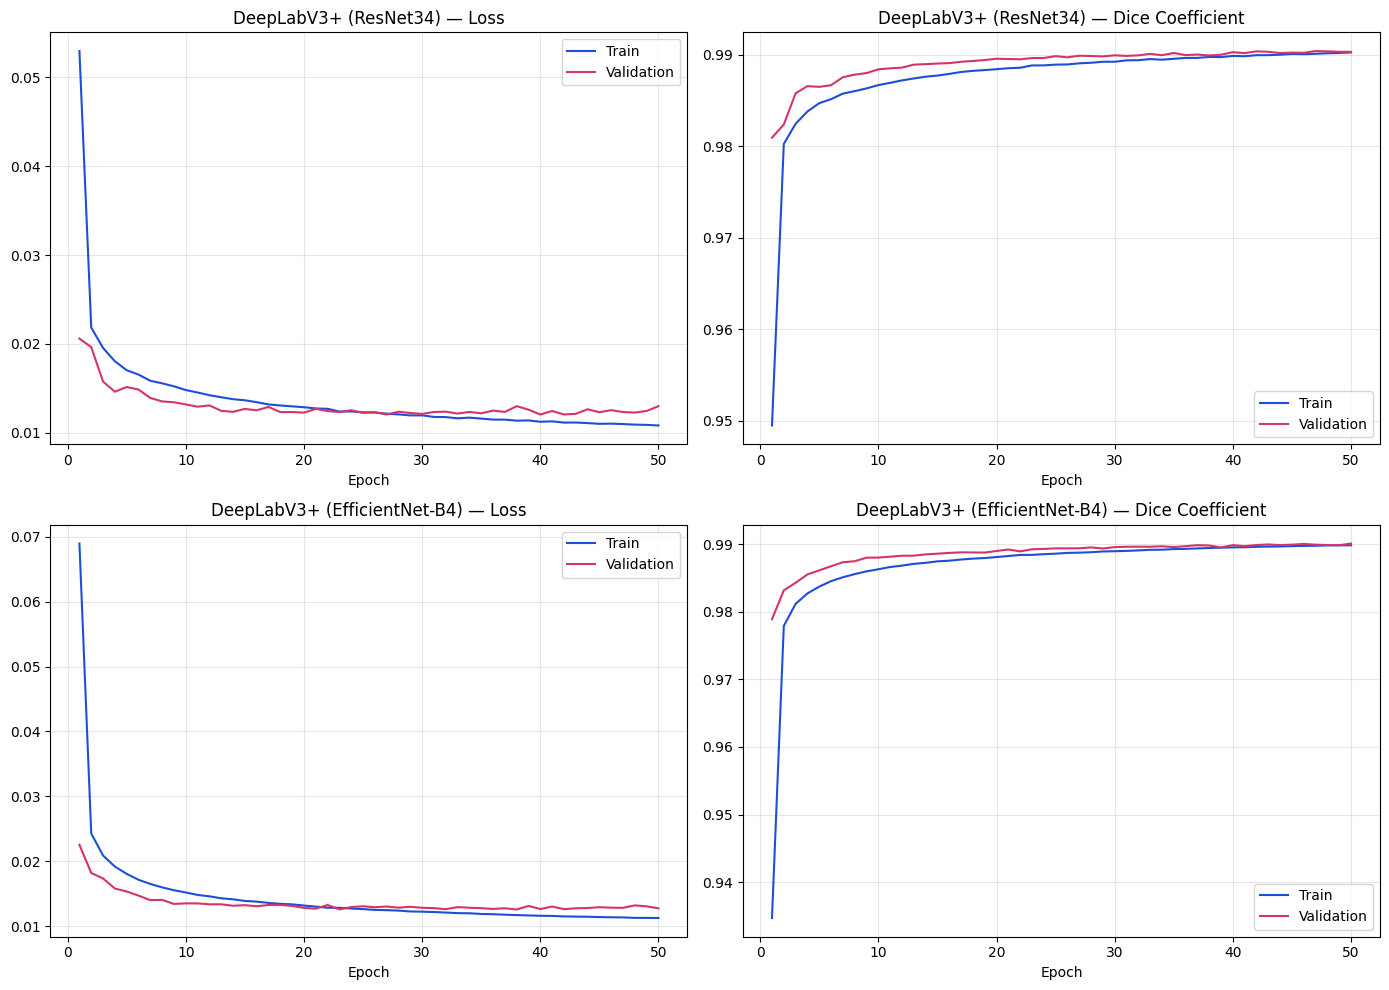

In [87]:
# ==== Training curves — each backbone shown separately ====
n_models = len(results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models), squeeze=False)

for row, (tag, res) in enumerate(results.items()):
    epochs_range = range(1, len(res["history"]["val_loss"]) + 1)

    axes[row, 0].plot(epochs_range, res["history"]["train_loss"], label="Train", color="#1D4ED8")
    axes[row, 0].plot(epochs_range, res["history"]["val_loss"], label="Validation", color="#D6336C")
    axes[row, 0].set_title(f"{res['display_name']} — Loss")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(epochs_range, res["history"]["train_dice"], label="Train", color="#1D4ED8")
    axes[row, 1].plot(epochs_range, res["history"]["val_dice"], label="Validation", color="#D6336C")
    axes[row, 1].set_title(f"{res['display_name']} — Dice Coefficient")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


<h2 style="color:#D6336C;">5. Evaluation</h2>

In [88]:
# ==== Detailed test-set evaluation — both backbones 
    print("=" * 60)
    print(res["display_name"])
    print("=" * 60)
    print(f"{'Test loss':<20}: {res['test_loss']:.4f}")
    print(f"{'Test pixel accuracy':<20}: {res['test_acc']:.4f}\n")

    print("Soft (softmax) Dice/IoU -- training-time surrogate, includes background:")
    for i, cls_name in enumerate(class_names):
        print(f"  {cls_name:<15} Dice: {res['dice_per_class'][i]:.4f}   IoU: {res['iou_per_class'][i]:.4f}")

    print("\nHard (argmax) Dice/IoU -- the reported metric, computed on the discrete prediction:")
    for i, cls_name in enumerate(class_names):
        print(f"  {cls_name:<15} Dice: {res['hard_dice_per_class'][i]:.4f}   IoU: {res['hard_iou_per_class'][i]:.4f}")

    r_dice, l_dice = res["per_image_dice_right"], res["per_image_dice_left"]
    print(f"\nPer-image hard Lung Dice -- right: mean {r_dice.mean():.4f}, median {np.median(r_dice):.4f}, std {r_dice.std():.4f}")
    print(f"Per-image hard Lung Dice -- left : mean {l_dice.mean():.4f}, median {np.median(l_dice):.4f}, std {l_dice.std():.4f}\n")


# ==== Backbone selection — on VALIDATIONx").
best_val_lung_dice = {tag: max(res["history"]["val_lung_dice"]) for tag, res in results.items()}

print("=" * 60)
print("BACKBONE COMPARISON (validation lung Dice)")
print("=" * 60)
for tag, res in results.items():
    print(f"{res['display_name']:<30}: {best_val_lung_dice[tag]:.4f}")

best_tag = max(results, key=lambda t: best_val_lung_dice[t])
print("-" * 60)
print(f"Best backbone (validation)  : {results[best_tag]['display_name']}")
print(f"Corresponding test lung Dice: {results[best_tag]['dice_per_class'][1:].mean():.4f} ")
print("=" * 60)

DeepLabV3+ (ResNet34)
Test loss           : 0.0116
Test pixel accuracy : 0.9951

Soft (softmax) Dice/IoU -- training-time surrogate, includes background:
  Background      Dice: 0.9962   IoU: 0.9925
  Right lung      Dice: 0.9885   IoU: 0.9774
  Left lung       Dice: 0.9869   IoU: 0.9743

Hard (argmax) Dice/IoU -- the reported metric, computed on the discrete prediction:
  Background      Dice: 0.9967   IoU: 0.9935
  Right lung      Dice: 0.9894   IoU: 0.9793
  Left lung       Dice: 0.9876   IoU: 0.9760

Per-image hard Lung Dice -- right: mean 0.9894, median 0.9928, std 0.0145
Per-image hard Lung Dice -- left : mean 0.9876, median 0.9922, std 0.0161

DeepLabV3+ (EfficientNet-B4)
Test loss           : 0.0120
Test pixel accuracy : 0.9950

Soft (softmax) Dice/IoU -- training-time surrogate, includes background:
  Background      Dice: 0.9962   IoU: 0.9923
  Right lung      Dice: 0.9883   IoU: 0.9768
  Left lung       Dice: 0.9866   IoU: 0.9736

Hard (argmax) Dice/IoU -- the reported metri

In [89]:
# ==== Reloading the best weights of each backbone for visualization ====
model_builders = {
    "deeplab_resnet34": build_model_resnet34,
    "deeplab_effb4": build_model_efficientnet_b4,
}

best_models = {}
for tag, builder in model_builders.items():
    m = builder()
    m.load_state_dict(torch.load(results[tag]["best_weights_path"], map_location=Config.DEVICE))
    m.eval()
    best_models[tag] = m

# Used throughout the rest of the notebook (error maps, Grad-CAM, deployment):
# the backbone with the best mean lung Dice on the test set.
best_model = best_models[best_tag]
print(f"Using {results[best_tag]['display_name']} for downstream visualization/explainability.")

preprocessing_fn = make_zscore_preprocessing(Config.NORM_MEAN, Config.NORM_STD)
test_dataset = LungSegmentationDataset(X_test, Y_test, preprocessing_fn, augment=False)


Using DeepLabV3+ (ResNet34) for downstream visualization/explainability.


In [90]:
def draw_lung_mask(img_gray, mask, right_color=(255, 0, 0), left_color=(0, 255, 0), alpha=0.4):
    """
    Overlays the right and left lungs on the grayscale image as a
    semi-transparent color fill.
    """
    overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

    for class_id, color in [(1, right_color), (2, left_color)]:
        class_mask = (mask == class_id).astype(np.uint8) * 255

        colored = np.zeros_like(overlay, dtype=np.uint8)
        colored[class_mask == 255] = color

        overlay = cv2.addWeighted(overlay, 1, colored, alpha, 0)

    return overlay

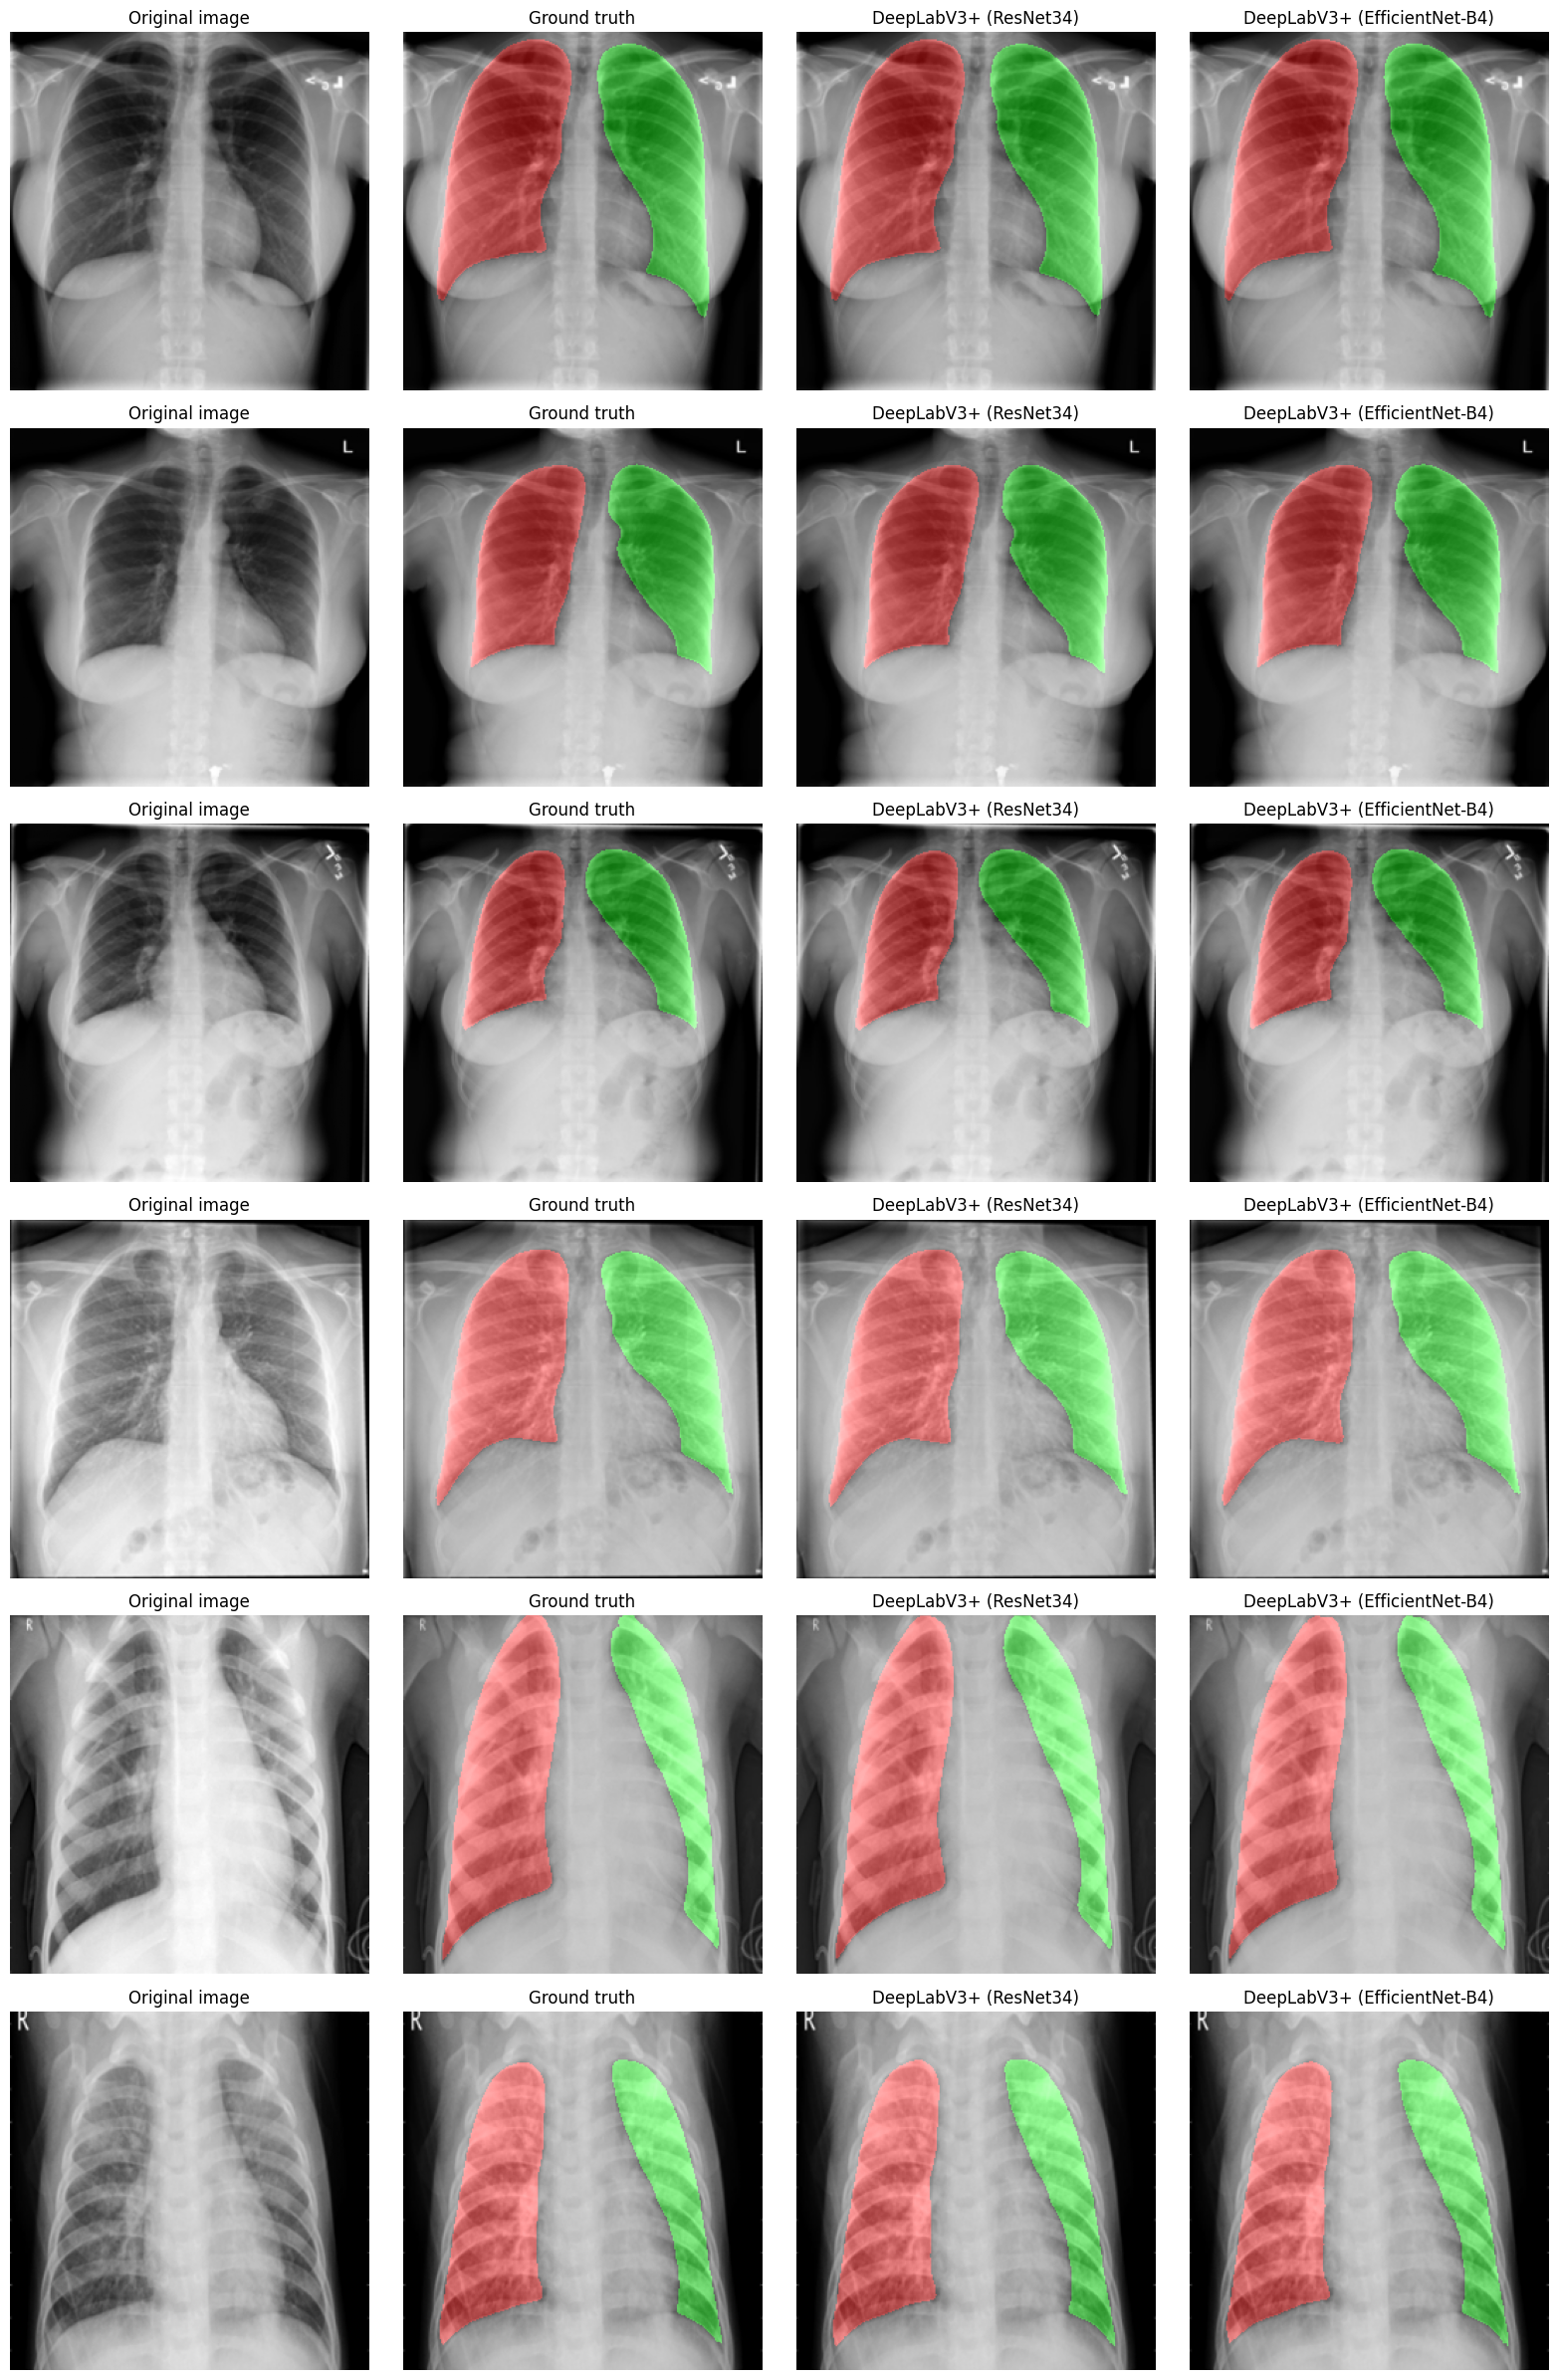

In [91]:
# ==== Predictions on test samples — ground truth vs. both backbones ====
# draw_lung_mask overlays the right/left lungs on the grayscale image as a
# semi-transparent color fill (see previous cell).
n_samples = 6
idxs = np.random.choice(len(X_test), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))

with torch.no_grad():
    for row, idx_s in enumerate(idxs):
        img_tensor, mask_true = test_dataset[idx_s]
        img_input = img_tensor.unsqueeze(0).to(Config.DEVICE)

        img_display = cv2.resize(X_test[idx_s], (Config.IMG_SIZE, Config.IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        mask_true_np = mask_true.numpy()
        overlay_true = draw_lung_mask(img_display, mask_true_np)

        axes[row, 0].imshow(img_display, cmap="gray")
        axes[row, 0].set_title("Original image")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(overlay_true)
        axes[row, 1].set_title("Ground truth")
        axes[row, 1].axis("off")

        for col, tag in zip((2, 3), ("deeplab_resnet34", "deeplab_effb4")):
            logits = best_models[tag](img_input)
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
            overlay_pred = draw_lung_mask(img_display, pred)

            axes[row, col].imshow(overlay_pred)
            axes[row, col].set_title(results[tag]["display_name"])
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()

<h3 style="color:#D6336C;">5.1 Explainability — Seg-Grad-CAM</h3>

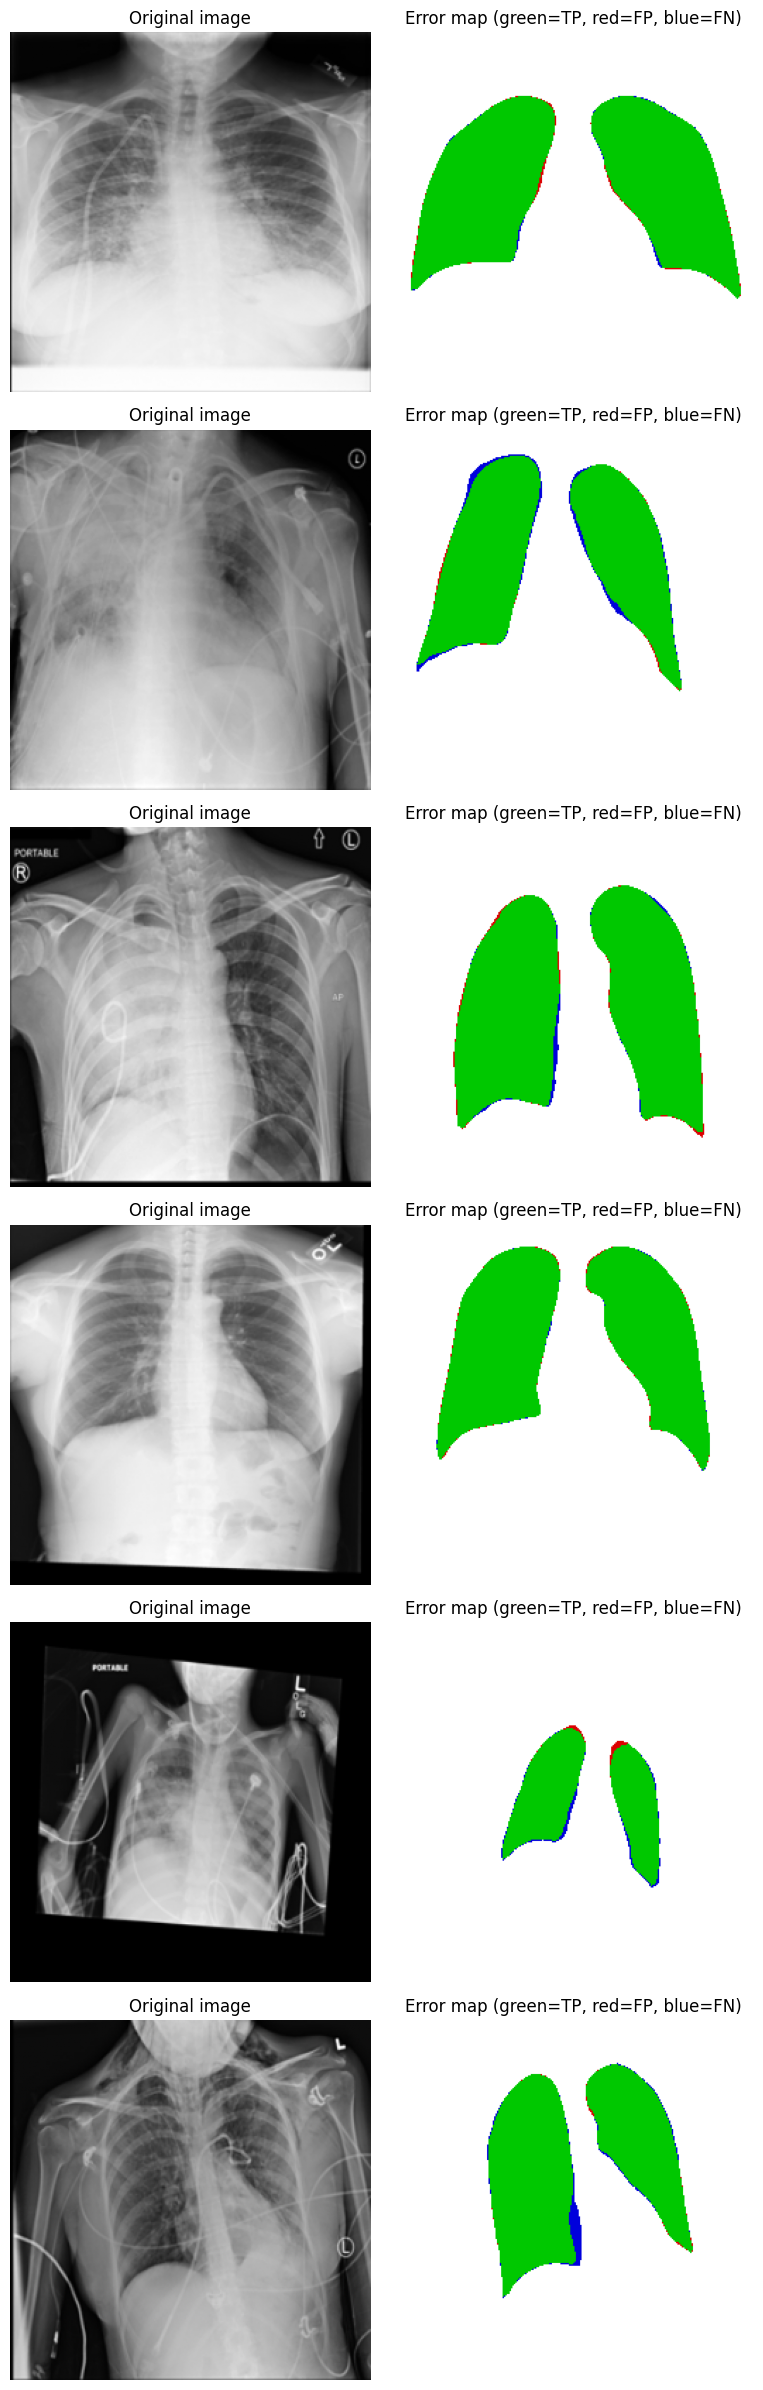

In [93]:
# ==== Error maps: false positives / false negatives vs. ground truth ====

def draw_error_map(mask_true, mask_pred):
    h, w = mask_true.shape
    error_map = np.full((h, w, 3), 255, dtype=np.uint8)

    true_fg = mask_true > 0
    pred_fg = mask_pred > 0

    error_map[true_fg & pred_fg] = (0, 200, 0)     # TP - green
    error_map[pred_fg & ~true_fg] = (220, 0, 0)    # FP - red
    error_map[true_fg & ~pred_fg] = (0, 0, 220)    # FN - blue

    return error_map


n_samples = 6
idxs = np.random.choice(len(X_test), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 2, figsize=(8, 4 * n_samples))

with torch.no_grad():
    for row, idx in enumerate(idxs):
        img_tensor, mask_true = test_dataset[idx]
        img_input = img_tensor.unsqueeze(0).to(Config.DEVICE)

        logits = best_model(img_input)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
        mask_true_np = mask_true.numpy()

        error_map = draw_error_map(mask_true_np, pred)

        img_display = cv2.resize(X_test[idx], (Config.IMG_SIZE, Config.IMG_SIZE), interpolation=cv2.INTER_LINEAR)

        axes[row, 0].imshow(img_display, cmap="gray")
        axes[row, 0].set_title("Original image")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(error_map)
        axes[row, 1].set_title("Error map (green=TP, red=FP, blue=FN)")
        axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Standard Grad-CAM assumes one score per class for the whole image (classification). For segmentation, the model outputs one score **per pixel per class**, so this adapts it ("Seg-Grad-CAM"): the gradient is taken of the **sum of a target class' logits over the whole spatial map**, with respect to a target layer's activations, instead of a single classification score. This shows which regions of the X-ray most influenced the prediction for a given lung — useful for checking the model is actually keying off lung anatomy rather than artifacts (printed L/R markers, image borders, equipment).

In [94]:
# ==== Seg-Grad-CAM: class-specific explainability for segmentation ====

class SegGradCAM:
    """
    Grad-CAM adapted for segmentation: computes the gradient of the SUM of a target
    class' logits (over the whole spatial map) w.r.t. a target layer's activations,
    rather than a single classification score.
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)                 # (1, C, H, W)
        score = output[:, target_class, :, :].sum()        # sum over all pixels of that class
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # global average pooling of gradients
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # normalize to [0, 1]
        return cam


def find_last_conv(module):
    """Returns the last nn.Conv2d found while walking a module's children — works for
    any decoder architecture (smp DeepLabV3Plus, or anything else), unlike hardcoding a
    specific submodule path.
"""
    last = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    return last


# Target layer: last conv of the decoder, the finest-resolution layer that still carries
# class-discriminative features, right before the segmentation head.
target_layer = find_last_conv(best_model.decoder)
grad_cam = SegGradCAM(best_model, target_layer)


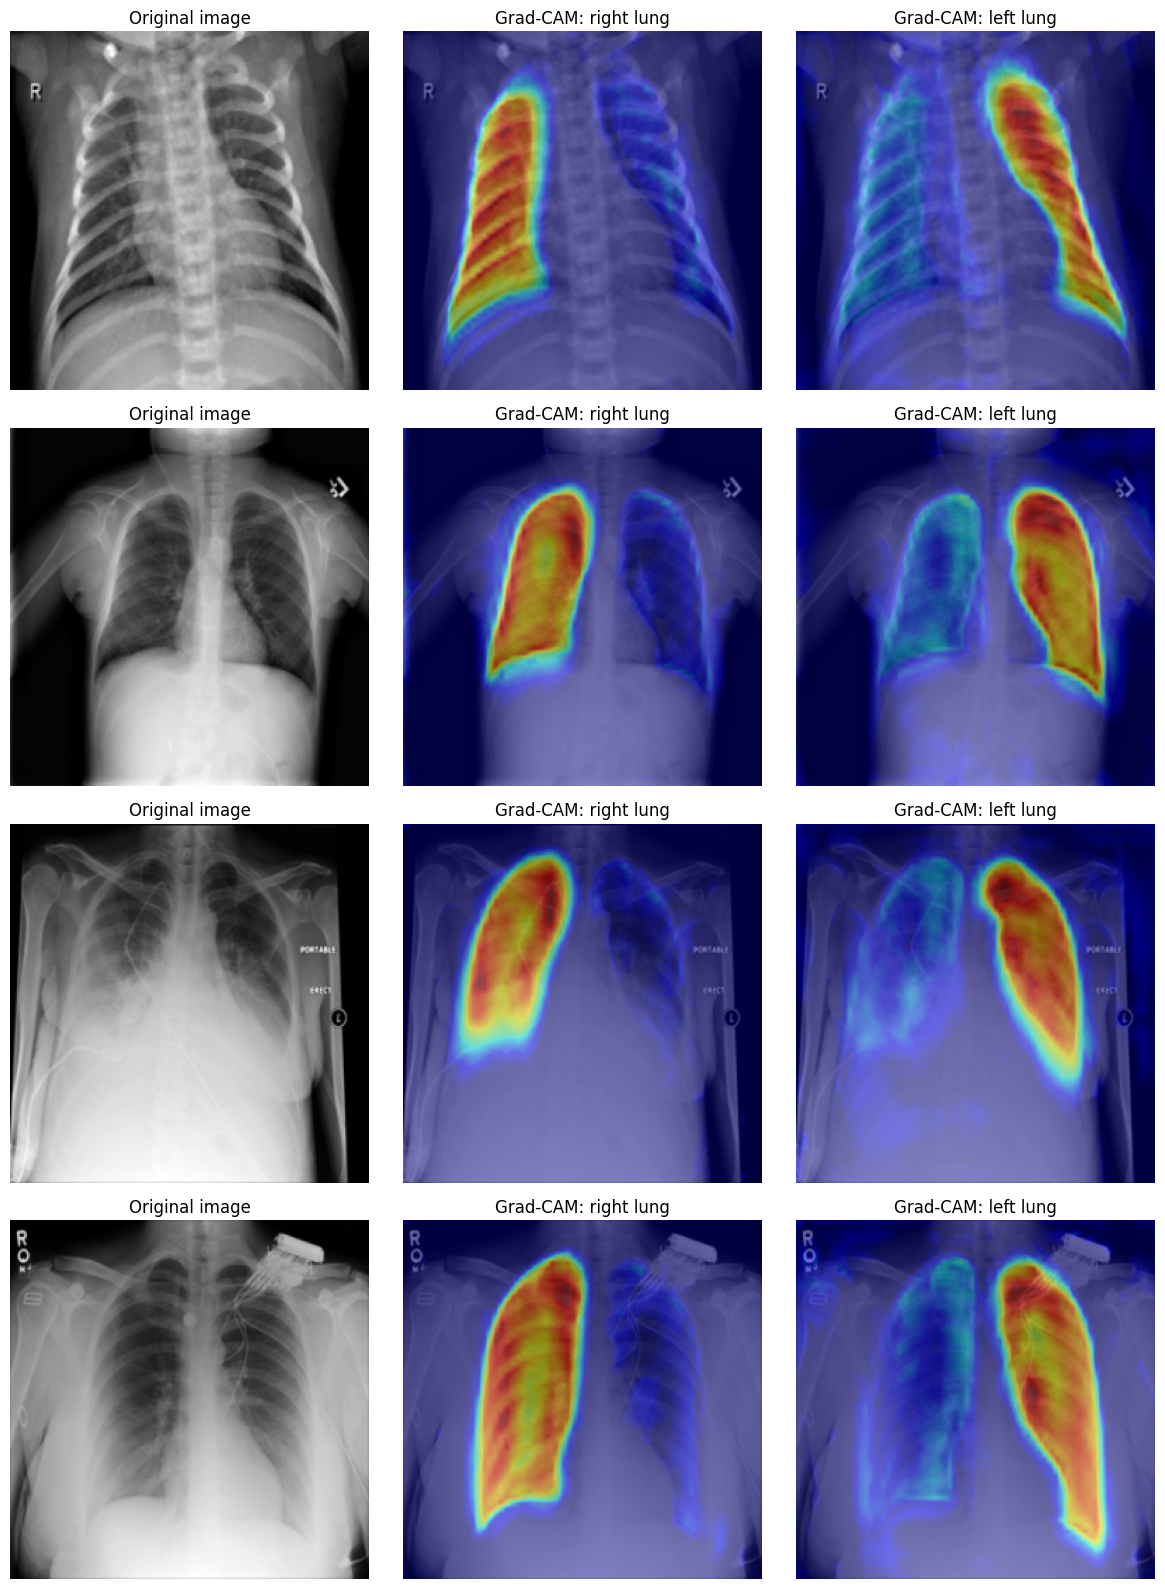

In [95]:
# ==== Grad-CAM for right and left lung, on a few test samples ====
n_samples = 4
idxs = np.random.choice(len(X_test), n_samples, replace=False)
fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
for row, idx in enumerate(idxs):
    img_tensor, _ = test_dataset[idx]
    img_input = img_tensor.unsqueeze(0).to(Config.DEVICE)

    # Resize to Config.IMG_SIZE to match the CAM resolution
    img_display = cv2.resize(X_test[idx], (Config.IMG_SIZE, Config.IMG_SIZE), interpolation=cv2.INTER_LINEAR)

    cam_right = grad_cam.generate(img_input, target_class=1)
    cam_left = grad_cam.generate(img_input, target_class=2)
    axes[row, 0].imshow(img_display, cmap="gray")
    axes[row, 0].set_title("Original image"); axes[row, 0].axis("off")
    axes[row, 1].imshow(img_display, cmap="gray")
    axes[row, 1].imshow(cam_right, cmap="jet", alpha=0.5)
    axes[row, 1].set_title("Grad-CAM: right lung"); axes[row, 1].axis("off")
    axes[row, 2].imshow(img_display, cmap="gray")
    axes[row, 2].imshow(cam_left, cmap="jet", alpha=0.5)
    axes[row, 2].set_title("Grad-CAM: left lung"); axes[row, 2].axis("off")
plt.tight_layout()
plt.show()

<h3 style="color:#D6336C;">5.2 Post-Training Robustness — Hard-Case Fine-Tuning</h3>

<h2 style="color:#D6336C;">6. Deployment</h2>

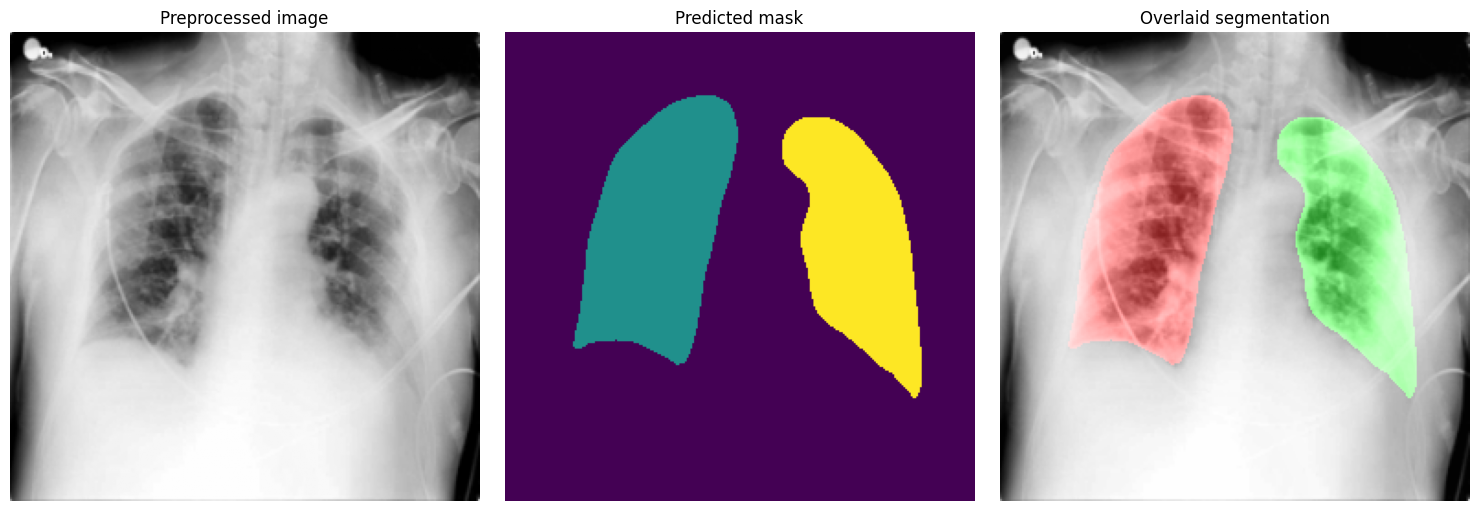

Classes present in prediction: [0 1 2]


In [96]:
def predict_lung_segmentation(image_path, model, show=True):
    """
    Takes the path of a raw chest X-ray and returns the predicted multiclass
    mask (0=background, 1=right lung, 2=left lung), along with the resized
    image used as model input.
    """
    model.eval()

    img_raw = load_gray(image_path)
    if img_raw is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    # Same deterministic pipeline as training (Dataset.__getitem__): percentile -> CLAHE -> resize.
    img_resized = prepare_image_array(img_raw)

    local_preprocessing_fn = make_zscore_preprocessing(Config.NORM_MEAN, Config.NORM_STD)

    img_norm = local_preprocessing_fn(img_resized).transpose(2, 0, 1).astype(np.float32)
    img_tensor = torch.from_numpy(img_norm).unsqueeze(0).to(Config.DEVICE)

    with torch.no_grad():
        logits = model(img_tensor)
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    if show:
        overlay = draw_lung_mask(img_resized, pred_mask)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img_resized, cmap="gray")
        axes[0].set_title("Preprocessed image")
        axes[0].axis("off")

        axes[1].imshow(pred_mask, cmap="viridis")
        axes[1].set_title("Predicted mask")
        axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title("Overlaid segmentation")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    return pred_mask, img_resized

demo_src = Config.SOURCES[0]
demo_fname = sorted(os.listdir(Config.IMG_PATHS[demo_src]))[0]
demo_path = os.path.join(Config.IMG_PATHS[demo_src], demo_fname)

pred_mask, img_used = predict_lung_segmentation(demo_path, best_model)
print("Classes present in prediction:", np.unique(pred_mask))

In [97]:
# ==== Saving both trained models + deployment config ====
deployment_config = {
    "img_size": Config.IMG_SIZE,
    "num_classes": Config.NUM_CLASSES,
    "class_names": class_names,
    "best_backbone": best_tag,
    "models": {},
}

for tag, res in results.items():
    final_model_path = os.path.join(Config.RESULTS_PATH, f"{tag}_final.pth")
    torch.save(best_models[tag].state_dict(), final_model_path)

    deployment_config["models"][tag] = {
        "architecture": "DeepLabV3+",
        "encoder": "resnet34" if tag == "deeplab_resnet34" else "timm-efficientnet-b4",
        "display_name": res["display_name"],
        "weights_path": final_model_path,
        "test_dice_per_class": res["dice_per_class"].tolist(),
        "test_iou_per_class": res["iou_per_class"].tolist(),
    }
    print(f"{res['display_name']} saved to {final_model_path}")

deployment_path = os.path.join(Config.RESULTS_PATH, "deployment_config.json")
with open(deployment_path, "w") as f:
    json.dump(deployment_config, f, indent=2)

print(f"\nDeployment config saved to: {deployment_path}")


DeepLabV3+ (ResNet34) saved to /kaggle/working/results/deeplab_resnet34_final.pth
DeepLabV3+ (EfficientNet-B4) saved to /kaggle/working/results/deeplab_effb4_final.pth

Deployment config saved to: /kaggle/working/results/deployment_config.json
